# Human Activity Recognition from Smartphone Sensor Data

## Motivation and aim

Recognising everyday activities from smartphone sensors could support daily activity monitoring, such as estimating time spent walking, sitting or standing.

Smartphone sensors capture how the body moves and changes position during daily activities. By learning these patterns, we can automatically recognise activities such as walking, sitting, and standing. The main challenge is to build a model that not only performs well on the training data, but also generalises to new people it has never seen before.

This project uses the [UCI Human Activity Recognition Using Smartphones dataset](https://archive.ics.uci.edu/dataset/240/human+activity+recognition+using+smartphones) to classify six activities. This notebook studies classical models using 561 engineered features. `NN.ipynb` examines LSTM and CNN-LSTM models using the supplied sensor sequences.

## Dataset and evaluation

The dataset contains 30 participants and six activities. Each window contains 128 samples from nine accelerometer and gyroscope channels recorded at 50 Hz. Model settings are selected with participant-based validation and evaluated on nine test participants. Accuracy measures overall correctness, while macro-F1 gives equal weight to every activity.

**Author:** Deepak Kushwaha  
**Course:** Data Mining & Machine Learning

## Contents

1. [Dataset and initial checks](#1-dataset-and-initial-checks)
2. [Exploratory analysis](#2-exploratory-analysis)
3. [Validation and preprocessing](#3-validation-and-preprocessing)
4. [Classical model selection](#4-classical-model-selection)
5. [Logistic regression interpretation](#5-logistic-regression-interpretation)
6. [Official test results](#6-official-test-results)
7. [Discussion and limitations](#7-discussion-and-limitations)
8. [Future work](#8-future-work)

In [35]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from sklearn import __version__ as sklearn_version

ROOT = Path.cwd()
while not (ROOT / "har_pipeline.py").is_file():
    if ROOT == ROOT.parent:
        raise FileNotFoundError("Open this notebook inside the HAR project.")
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
from har_pipeline import load_har_data, CorrelationFilter, ACTIVITIES

SEED = 42
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})
activity_labels = [name.replace("_", " ").title() for name in ACTIVITIES]
activity_colors = dict(zip(ACTIVITIES, sns.color_palette("colorblind", 6)))
print("scikit-learn:", sklearn_version)


scikit-learn: 1.9.0


<a id="1-dataset-and-initial-checks"></a>

## 1. Dataset and initial checks

The [UCI HAR dataset](https://archive.ics.uci.edu/dataset/240/human+activity+recognition+using+smartphones) contains waist-mounted smartphone recordings from 30 adults. Signals were sampled at 50 Hz and divided into 128-sample windows with 50% overlap. The target is one of six activities: walking, walking upstairs, walking downstairs, sitting, standing or laying.

The official split contains 21 training participants and nine test participants. Subject IDs are used only to keep people separate during validation. The predictors are either 561 engineered time- and frequency-domain features or nine filtered sensor channels. Here, raw signals means the supplied windowed channels before project standardisation.

The main challenges are high dimensionality, correlated features, repeated windows from each participant and overlap between sitting and standing. The controlled recording protocol also limits conclusions about unrestricted daily use.

In [36]:
data = load_har_data()
train = data["train"]
FEATURES = [c for c in train.columns if c not in {"subject", "Activity"}]
X_train = train[FEATURES]
y_train = train["Activity"].to_numpy()
groups = train["subject"].to_numpy()
assert len(FEATURES) == 561
assert set(groups).isdisjoint(data["subjects_test"])
assert np.isfinite(X_train.to_numpy()).all()
display(train.head())
display(
    pd.DataFrame(
        {
            "training_windows": [len(train)],
            "training_subjects": [len(np.unique(groups))],
            "engineered_features": [len(FEATURES)],
            "missing_values": [int(X_train.isna().sum().sum())],
            "duplicate_training_rows": [int(train.duplicated().sum())],
        }
    )
)


,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",subject,Activity
0,0.288585,-0.020294,-0.132905,-0.995279,-0.983111,-0.913526,-0.995112,-0.983185,-0.923527,-0.934724,...,-0.710304,-0.112754,0.030400,-0.464761,-0.018446,-0.841247,0.179941,-0.058627,1,STANDING
1,0.278419,-0.016411,-0.123520,-0.998245,-0.975300,-0.960322,-0.998807,-0.974914,-0.957686,-0.943068,...,-0.861499,0.053477,-0.007435,-0.732626,0.703511,-0.844788,0.180289,-0.054317,1,STANDING
2,0.279653,-0.019467,-0.113462,-0.995380,-0.967187,-0.978944,-0.996520,-0.963668,-0.977469,-0.938692,...,-0.760104,-0.118559,0.177899,0.100699,0.808529,-0.848933,0.180637,-0.049118,1,STANDING
3,0.279174,-0.026201,-0.123283,-0.996091,-0.983403,-0.990675,-0.997099,-0.982750,-0.989302,-0.938692,...,-0.482845,-0.036788,-0.012892,0.640011,-0.485366,-0.848649,0.181935,-0.047663,1,STANDING
4,0.276629,-0.016570,-0.115362,-0.998139,-0.980817,-0.990482,-0.998321,-0.979672,-0.990441,-0.942469,...,-0.699205,0.123320,0.122542,0.693578,-0.615971,-0.847865,0.185151,-0.043892,1,STANDING


,training_windows,training_subjects,engineered_features,missing_values,duplicate_training_rows
0,7352,21,561,0,0


The training set contains 7,352 windows and 561 predictors. There are no missing or infinite values, and the official test participants are separate. All exploratory analysis uses training data only.

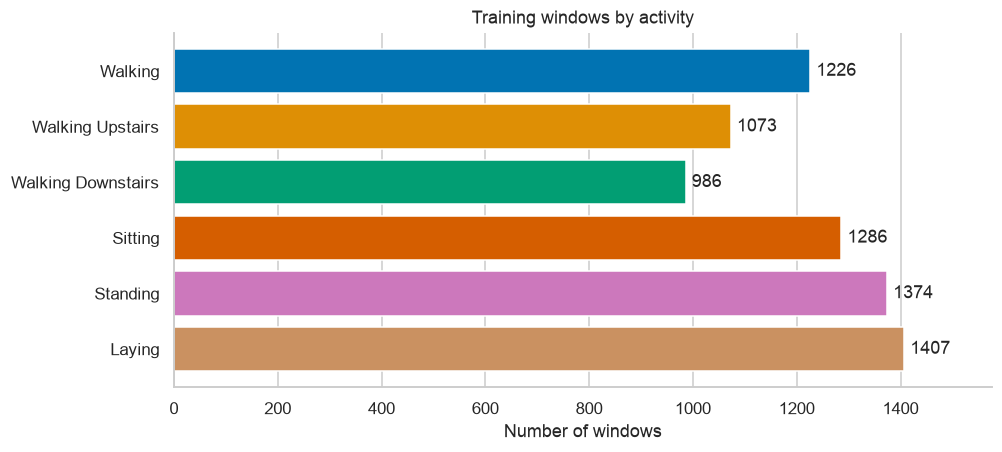

Largest/smallest class ratio: 1.43


In [37]:
counts = train["Activity"].value_counts().reindex(ACTIVITIES)
fig, ax = plt.subplots(figsize=(9, 4), layout="constrained")
bars = ax.barh(activity_labels, counts, color=[activity_colors[a] for a in ACTIVITIES])
ax.bar_label(bars, padding=4)
ax.invert_yaxis()
ax.set(
    title="Training windows by activity", xlabel="Number of windows", xlim=(0, counts.max() * 1.12)
)
ax.grid(axis="y", visible=False)
plt.show()
print(f"Largest/smallest class ratio: {counts.max() / counts.min():.2f}")


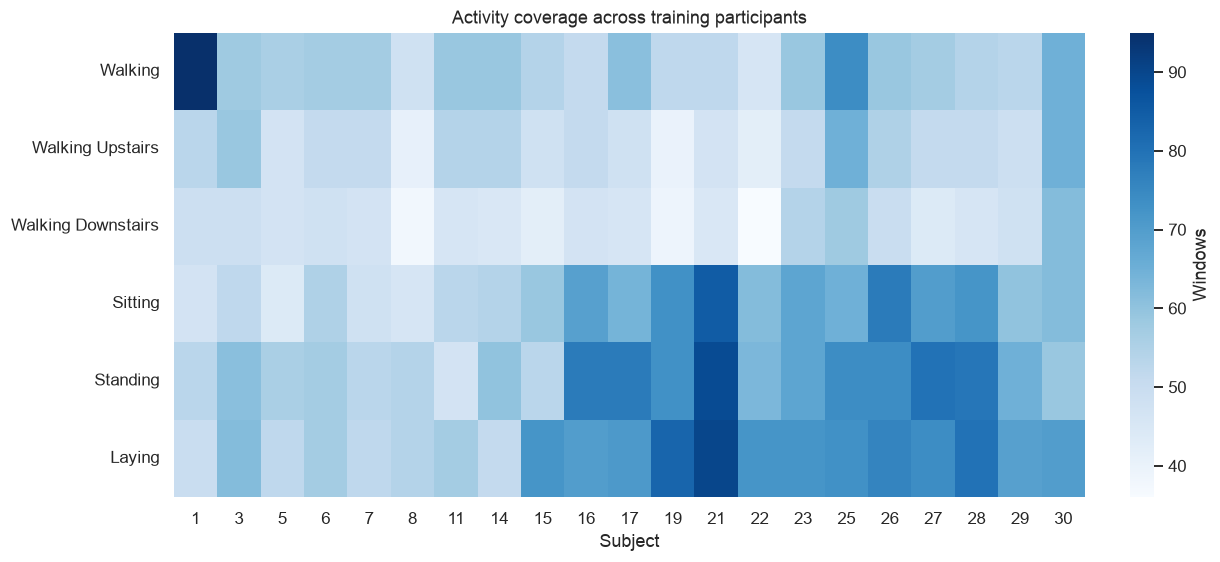

In [38]:
subject_counts = pd.crosstab(train["subject"], train["Activity"]).reindex(columns=ACTIVITIES)
fig, ax = plt.subplots(figsize=(11, 5), layout="constrained")
sns.heatmap(
    subject_counts.T,
    cmap="Blues",
    ax=ax,
    yticklabels=activity_labels,
    cbar_kws={"label": "Windows"},
)
ax.set(title="Activity coverage across training participants", xlabel="Subject", ylabel="")
ax.tick_params(axis="y", rotation=0)
plt.show()


The largest class is 1.43 times the smallest, so no resampling is used. Participant contributions vary more than class totals. Macro-F1 is therefore reported alongside accuracy.

<a id="2-exploratory-analysis"></a>

## 2. Exploratory analysis

### 2.1. Raw signals and feature distributions

The plots show one body-acceleration window per activity. They are individual examples rather than average patterns.

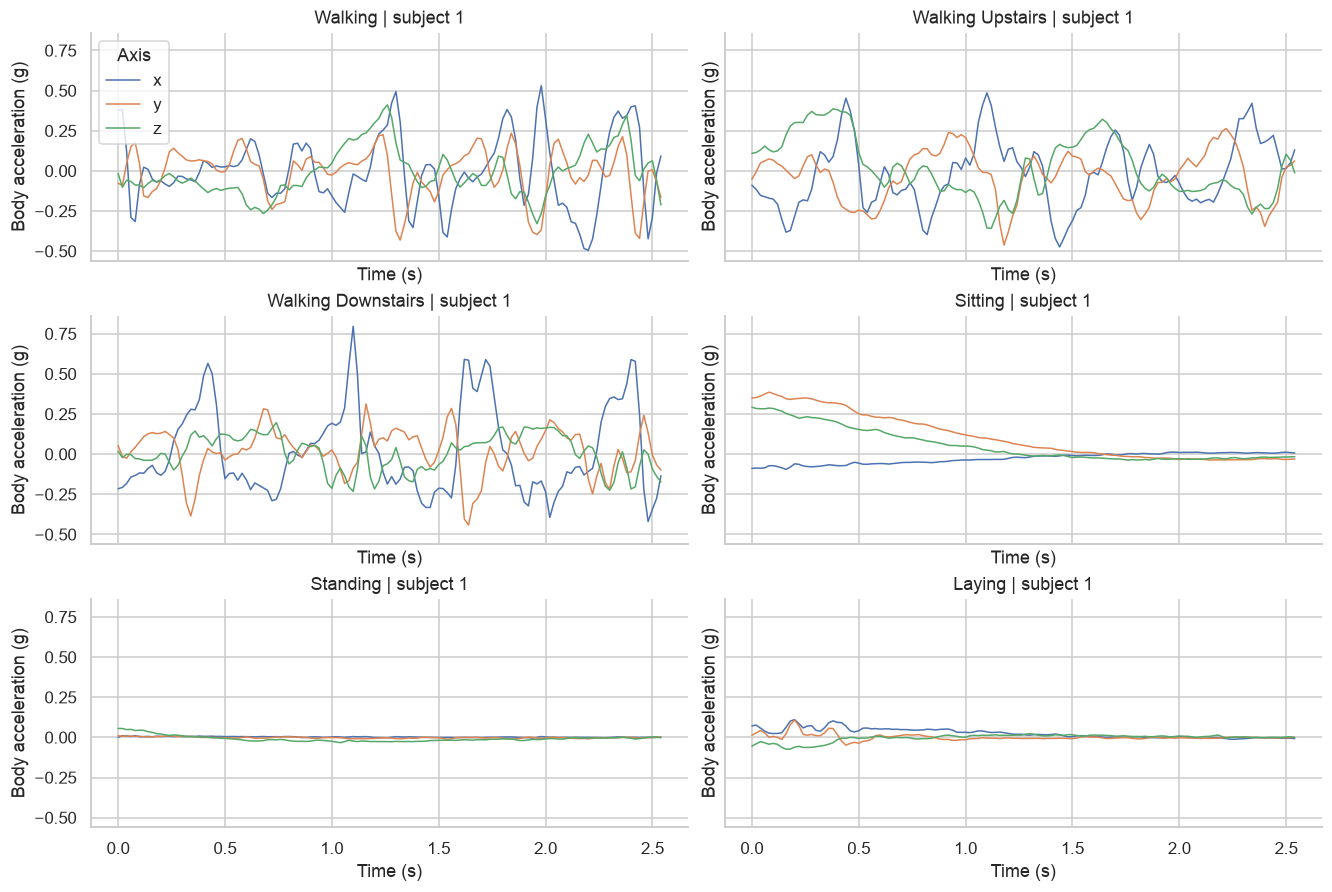

In [39]:
fig, axes = plt.subplots(3, 2, figsize=(12, 8), sharex=True, sharey=True, layout="constrained")
time = np.arange(128) / 50
for ax, activity, label in zip(axes.flat, ACTIVITIES, activity_labels):
    row = np.flatnonzero(y_train == activity)[0]
    for j, axis in enumerate("xyz"):
        ax.plot(time, data["raw_train"][row, :, j], label=axis, linewidth=1)
    ax.set(
        title=f"{label} | subject {groups[row]}", xlabel="Time (s)", ylabel="Body acceleration (g)"
    )
axes[0, 0].legend(title="Axis")
plt.show()


Movement activities show greater acceleration changes. Stationary windows are quieter, but posture also depends on phone orientation relative to gravity.

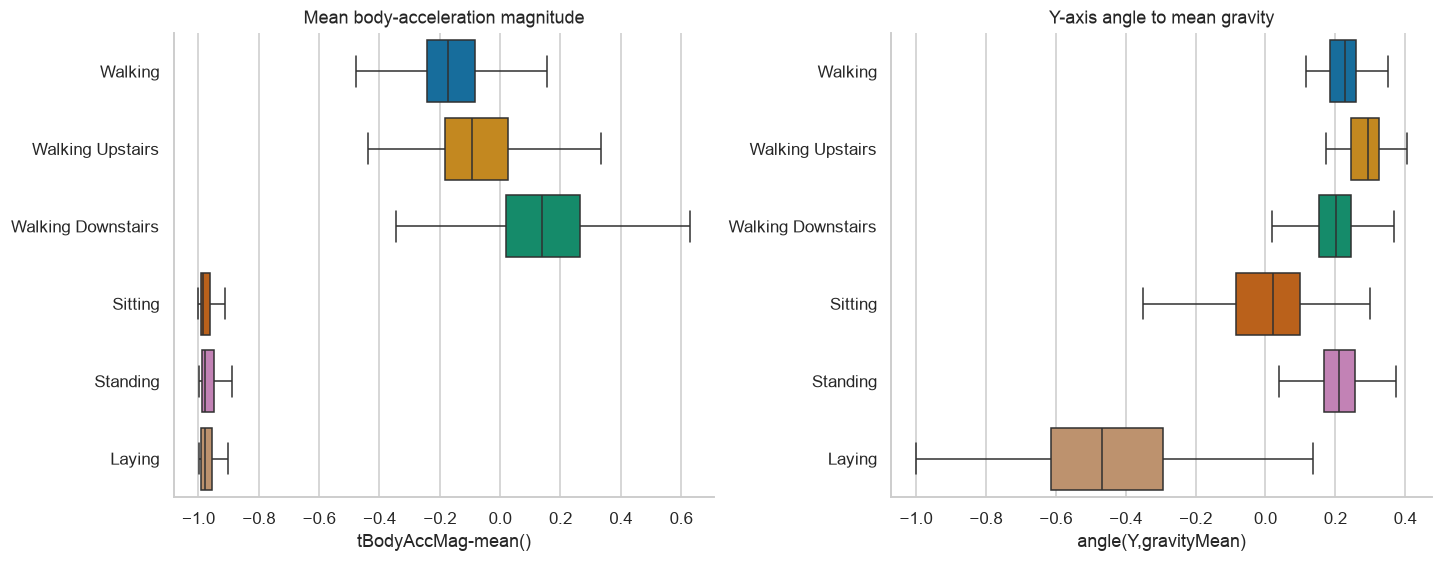

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), layout="constrained")
features_to_plot = ["tBodyAccMag-mean()", "angle(Y,gravityMean)"]
titles = ["Mean body-acceleration magnitude", "Y-axis angle to mean gravity"]
for ax, feature, title in zip(axes, features_to_plot, titles):
    sns.boxplot(
        data=train,
        y="Activity",
        x=feature,
        order=ACTIVITIES,
        hue="Activity",
        palette=activity_colors,
        legend=False,
        showfliers=False,
        ax=ax,
    )
    ax.set(title=title, xlabel=feature, ylabel="")
    ax.set_yticks(range(6), activity_labels)
plt.show()


Movement magnitude separates dynamic from stationary activities, while the gravity angle distinguishes laying. Sitting and standing still overlap. Outliers are hidden only in the plot and remain in the data.

#### Movement and posture in the same view

This joint view shows how movement magnitude and gravity orientation complement one another. It is descriptive and is not used for model selection.

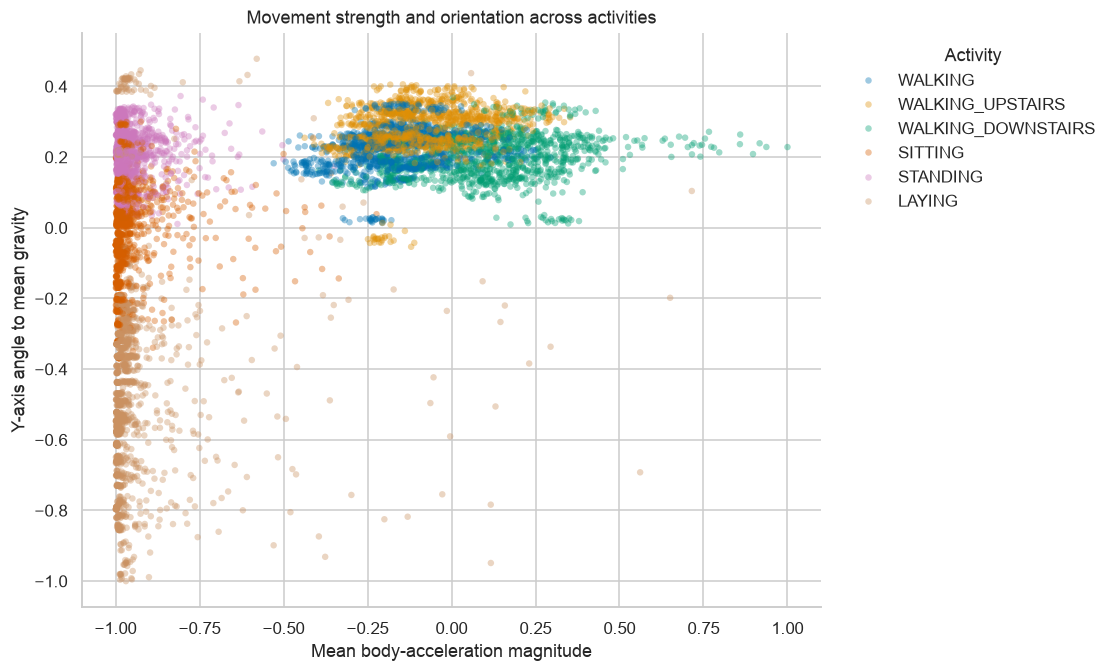

In [41]:
fig, ax = plt.subplots(figsize=(10, 6), layout="constrained")
sns.scatterplot(
    data=train,
    x="tBodyAccMag-mean()",
    y="angle(Y,gravityMean)",
    hue="Activity",
    hue_order=ACTIVITIES,
    palette=activity_colors,
    s=18,
    alpha=0.38,
    linewidth=0,
    ax=ax,
)
ax.set(
    title="Movement strength and orientation across activities",
    xlabel="Mean body-acceleration magnitude",
    ylabel="Y-axis angle to mean gravity",
)
ax.legend(title="Activity", bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False)
plt.show()

Walking activities show stronger movement, while laying separates mainly through orientation. Sitting and standing remain close on both measurements.

#### Raw sensor intensity across participants

Root mean square (RMS) summarizes each three-axis signal within a window. One median is then calculated for every participant and activity so that people with more windows do not dominate the comparison.

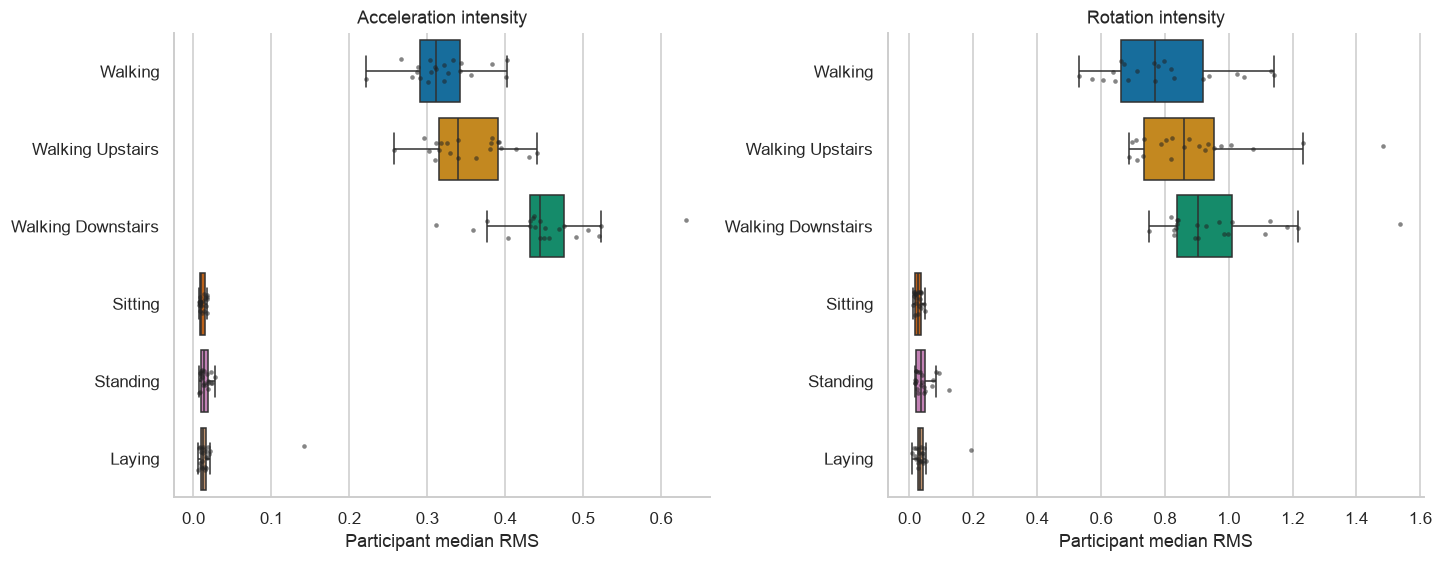

In [42]:
raw_windows = data["raw_train"]
body_acceleration_rms = np.sqrt(
    np.mean(np.sum(raw_windows[:, :, 0:3] ** 2, axis=2), axis=1)
)
body_gyroscope_rms = np.sqrt(
    np.mean(np.sum(raw_windows[:, :, 3:6] ** 2, axis=2), axis=1)
)

raw_summary = pd.DataFrame(
    {
        "subject": groups,
        "Activity": y_train,
        "Body acceleration RMS": body_acceleration_rms,
        "Body gyroscope RMS": body_gyroscope_rms,
    }
)
participant_signal_summary = (
    raw_summary.groupby(["subject", "Activity"], as_index=False)[
        ["Body acceleration RMS", "Body gyroscope RMS"]
    ]
    .median()
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5), layout="constrained")
for ax, measure, title in zip(
    axes,
    ["Body acceleration RMS", "Body gyroscope RMS"],
    ["Acceleration intensity", "Rotation intensity"],
):
    sns.boxplot(
        data=participant_signal_summary,
        y="Activity",
        x=measure,
        order=ACTIVITIES,
        hue="Activity",
        palette=activity_colors,
        legend=False,
        showfliers=False,
        ax=ax,
    )
    sns.stripplot(
        data=participant_signal_summary,
        y="Activity",
        x=measure,
        order=ACTIVITIES,
        color="#222222",
        size=3,
        alpha=0.55,
        jitter=0.16,
        ax=ax,
    )
    ax.set(title=title, xlabel="Participant median RMS", ylabel="")
    ax.set_yticks(range(len(ACTIVITIES)), activity_labels)
plt.show()

Movement activities have greater acceleration and rotation intensity. Variation between participants supports grouped validation. The three stationary classes have similarly low intensity, so gravity and orientation information remain necessary.

#### Frequency content of movement

Welch power spectra show how body-acceleration magnitude varies across frequencies. Lines are activity medians and shaded bands cover the middle 50% of training windows.

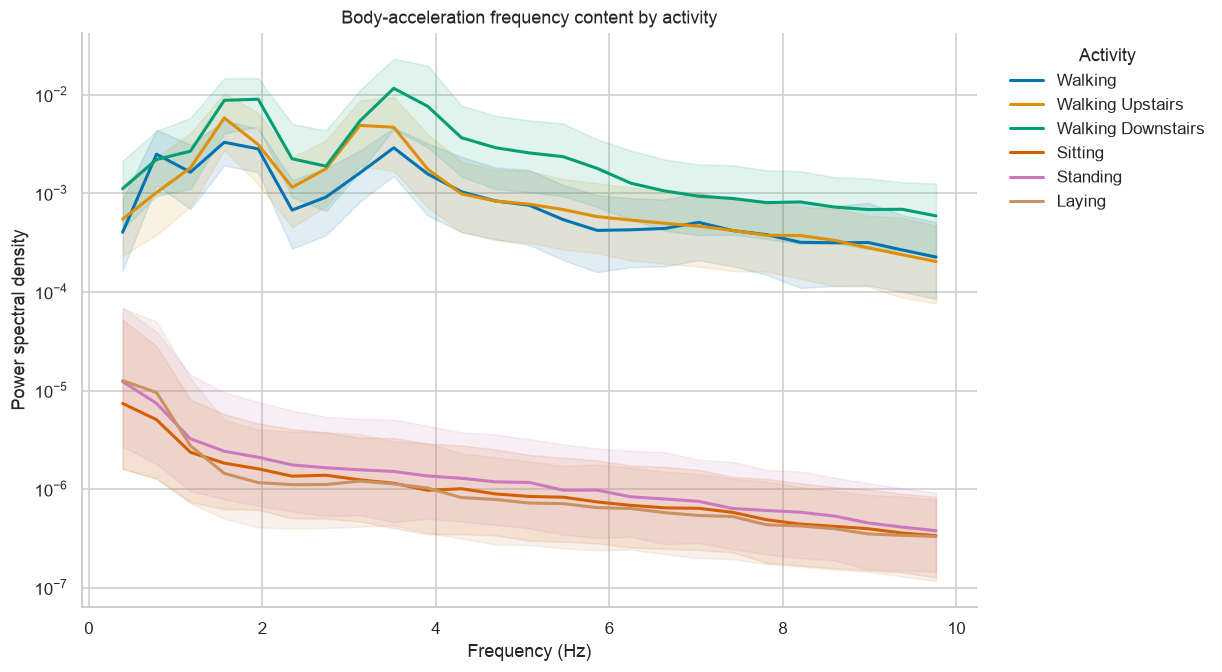

In [43]:
from scipy.signal import welch

body_acceleration_magnitude = np.linalg.norm(data["raw_train"][:, :, 0:3], axis=2)
frequencies, power_spectra = welch(
    body_acceleration_magnitude,
    fs=50,
    nperseg=128,
    axis=1,
    detrend="constant",
    scaling="density",
)
frequency_range = (frequencies > 0) & (frequencies <= 10)

fig, ax = plt.subplots(figsize=(11, 6), layout="constrained")
for activity, label in zip(ACTIVITIES, activity_labels):
    activity_power = power_spectra[y_train == activity][:, frequency_range]
    median_power = np.median(activity_power, axis=0)
    lower_quartile, upper_quartile = np.percentile(activity_power, [25, 75], axis=0)
    color = activity_colors[activity]
    ax.plot(
        frequencies[frequency_range],
        median_power,
        color=color,
        linewidth=2,
        label=label,
    )
    ax.fill_between(
        frequencies[frequency_range],
        lower_quartile,
        upper_quartile,
        color=color,
        alpha=0.12,
    )

ax.set_yscale("log")
ax.set(
    title="Body-acceleration frequency content by activity",
    xlabel="Frequency (Hz)",
    ylabel="Power spectral density",
)
ax.legend(title="Activity", bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False)
plt.show()

Walking activities contain much more periodic power than stationary activities. Walking and walking upstairs peak near 1.6 Hz, while walking downstairs has a stronger higher-frequency peak. Frequency features help describe movement but do not separate stationary postures.

### 2.2. Correlated features


Pairs with |correlation| > 0.90: 8206


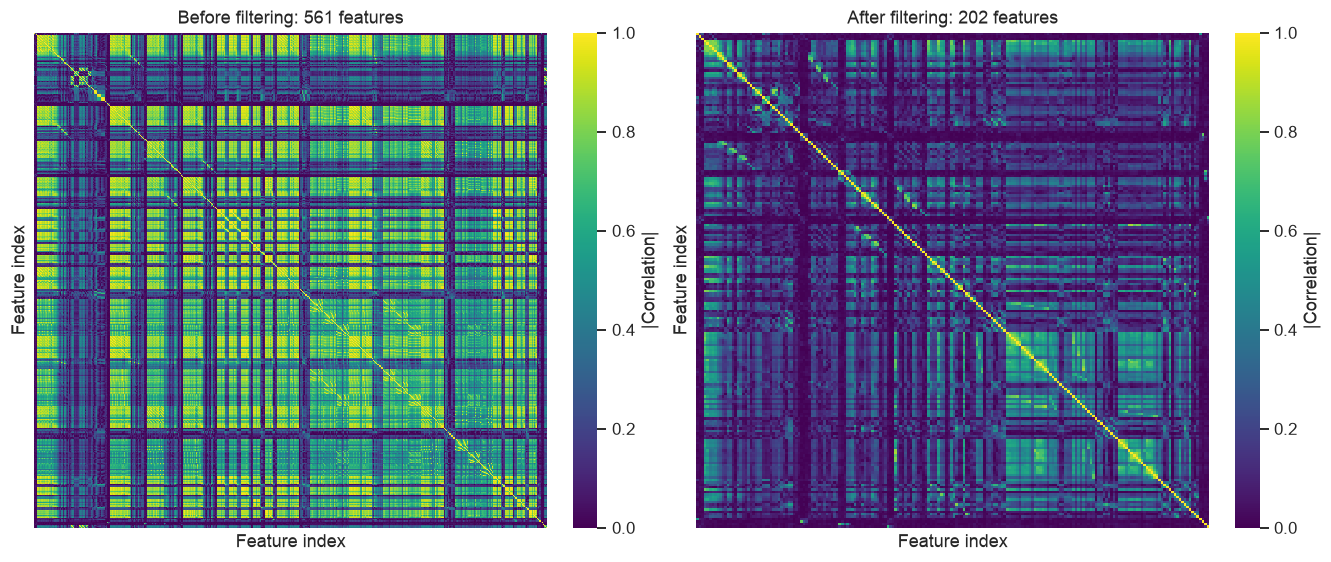

In [44]:
corr = X_train.corr().abs()
upper = np.triu(np.ones(corr.shape, dtype=bool), k=1)
print("Pairs with |correlation| > 0.90:", int(((corr > 0.90).to_numpy() & upper).sum()))

# This fit is for exploration only. Modeling uses a fresh filter inside each CV fold.
eda_filter = CorrelationFilter(threshold=0.90).fit(X_train)
retained_features = eda_filter.get_feature_names_out()
X_eda = X_train[retained_features]

fig, axes = plt.subplots(1, 2, figsize=(12, 5), layout="constrained")
for ax, frame, title in zip(
    axes,
    [X_train, X_eda],
    ["Before filtering: 561 features", f"After filtering: {len(retained_features)} features"],
):
    sns.heatmap(
        frame.corr().abs(),
        ax=ax,
        cmap="viridis",
        vmin=0,
        vmax=1,
        xticklabels=False,
        yticklabels=False,
        cbar_kws={"label": "|Correlation|"},
    )
    ax.set(title=title, xlabel="Feature index", ylabel="Feature index")
plt.show()


There are 8,206 feature pairs with absolute correlation above 0.90. The filter retains 202 of 561 features by dropping a later feature when it is strongly correlated with an earlier one.

The heatmaps use absolute correlations, so negative relationships are included. The retained set shown here is exploratory; every validation fold fits its own filter using only its fitting participants. The fixed 0.90 threshold is not a claim of optimality.

### 2.3. PCA and t-SNE


In [45]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score

eda_scaler = StandardScaler()
X_eda_scaled = eda_scaler.fit_transform(X_eda)
eda_pca = PCA(n_components=0.95, svd_solver="full")
eda_coords = eda_pca.fit_transform(X_eda_scaled)
pca_variance = eda_pca.explained_variance_ratio_
print(f"Components needed for 95% variance: {eda_pca.n_components_}")


Components needed for 95% variance: 113


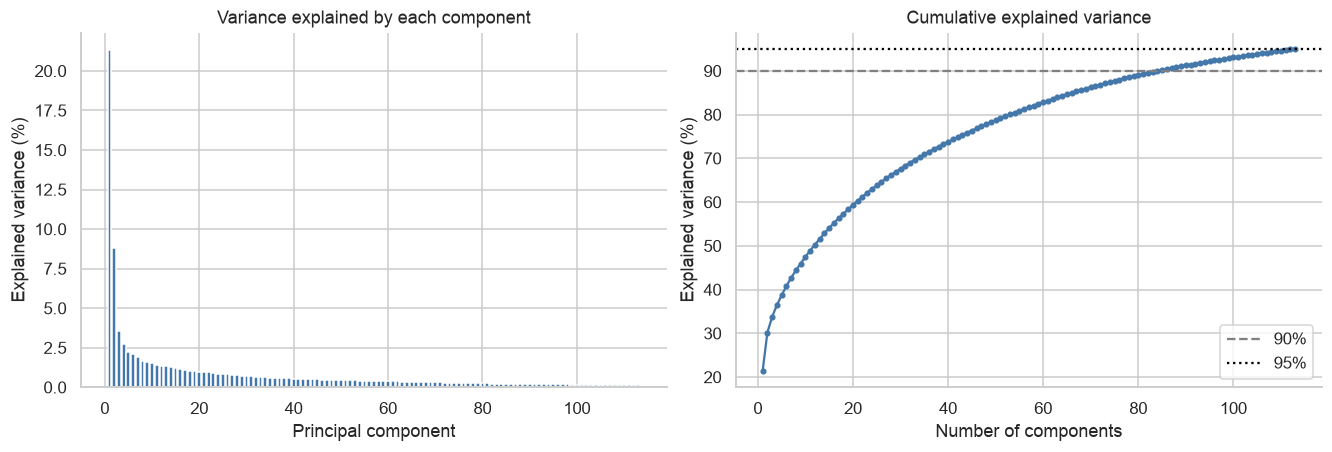

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), layout="constrained")
component_numbers = np.arange(1, len(pca_variance) + 1)
axes[0].bar(component_numbers, pca_variance * 100, color="#4477AA")
axes[0].set(
    title="Variance explained by each component",
    xlabel="Principal component",
    ylabel="Explained variance (%)",
)
axes[1].plot(component_numbers, np.cumsum(pca_variance) * 100, marker=".", color="#4477AA")
axes[1].axhline(90, ls="--", color="grey", label="90%")
axes[1].axhline(95, ls=":", color="black", label="95%")
axes[1].set(
    title="Cumulative explained variance",
    xlabel="Number of components",
    ylabel="Explained variance (%)",
)
axes[1].legend()
plt.show()


PCA needs 113 components to retain 95% of the variance in the 202 filtered features. The first component explains about 21%, so information is spread across many directions. Model tuning compares 90% and 95% variance thresholds.

t-SNE provides a nonlinear view of local neighbourhoods using the training PCA coordinates. Perplexities 30 and 50 give a simple sensitivity check. Neither embedding is used for classification.

In [47]:
from sklearn.manifold import TSNE

tsne_views = {}
for perplexity in [30, 50]:
    tsne = TSNE(
        n_components=2,
        perplexity=perplexity,
        init="pca",
        learning_rate="auto",
        max_iter=1000,
        random_state=SEED,
    )
    tsne_views[perplexity] = tsne.fit_transform(eda_coords)
    print(f"Finished t-SNE with perplexity {perplexity}")


Finished t-SNE with perplexity 30
Finished t-SNE with perplexity 50


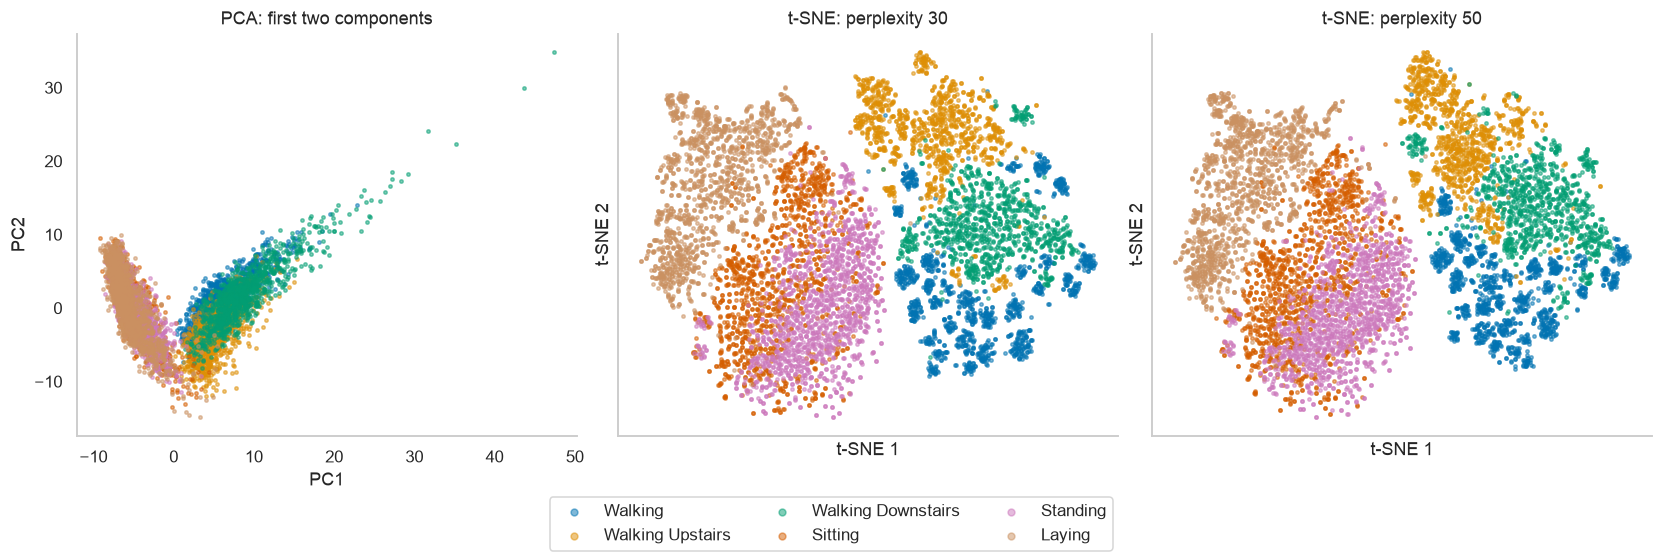

In [48]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5), layout="constrained")
views = [eda_coords[:, :2], tsne_views[30], tsne_views[50]]
titles = ["PCA: first two components", "t-SNE: perplexity 30", "t-SNE: perplexity 50"]
for ax, coordinates, title in zip(axes, views, titles):
    for activity, label in zip(ACTIVITIES, activity_labels):
        mask = y_train == activity
        ax.scatter(
            coordinates[mask, 0],
            coordinates[mask, 1],
            s=5,
            alpha=0.5,
            color=activity_colors[activity],
            label=label,
            rasterized=True,
        )
    ax.set_title(title)
    ax.grid(False)
axes[0].set(xlabel="PC1", ylabel="PC2")
for ax in axes[1:]:
    ax.set(xlabel="t-SNE 1", ylabel="t-SNE 2", xticks=[], yticks=[])
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="outside lower center", ncol=3, markerscale=2)
plt.show()


t-SNE separates the movement activities more clearly than the first two PCA components, while sitting and standing remain mixed. The pattern is similar at both perplexities.

These are training-data visualizations. Distances between t-SNE groups have no direct physical meaning, and visible separation is not a measure of prediction performance.

### 2.4. Clusters and activity labels


Training adjusted Rand index: 0.328


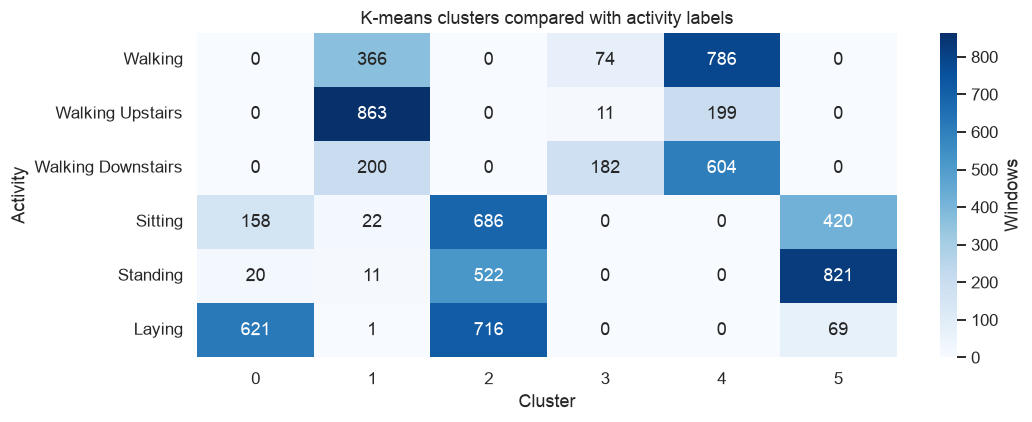

In [49]:
clusters = KMeans(n_clusters=6, n_init=10, random_state=SEED).fit_predict(eda_coords)
print(f"Training adjusted Rand index: {adjusted_rand_score(y_train, clusters):.3f}")
plt.figure(figsize=(10, 4))
sns.heatmap(
    pd.crosstab(pd.Series(y_train, name="Activity"), pd.Series(clusters, name="Cluster")).reindex(
        ACTIVITIES
    ),
    annot=True,
    fmt="d",
    cmap="Blues",
    yticklabels=activity_labels,
    cbar_kws={"label": "Windows"},
)
plt.title("K-means clusters compared with activity labels")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


The adjusted Rand index is 0.328, so the six K-means clusters only partly match the activity labels. K-means finds compact groups in the 113-component PCA representation; it is not fitted on t-SNE. Labels are used only to evaluate the clustering.

### 2.5. Unusual training windows


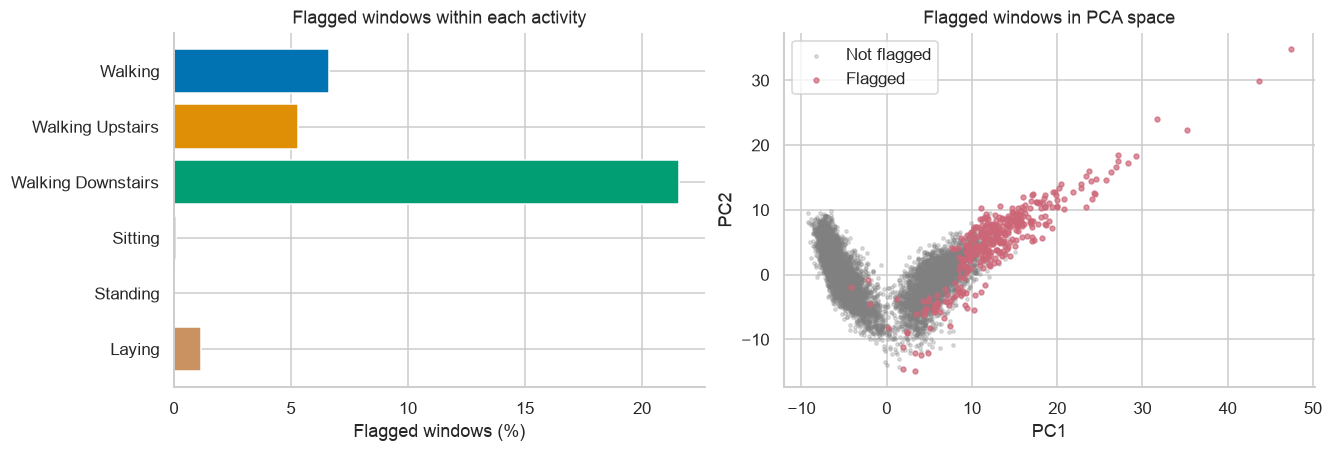

Flagged 368 of 7352 training windows


,Flagged,Within-activity rate (%)
Activity,,
WALKING,81,6.61
WALKING_UPSTAIRS,57,5.31
WALKING_DOWNSTAIRS,213,21.60
SITTING,1,0.08
STANDING,0,0.00
LAYING,16,1.14


In [50]:
from sklearn.ensemble import IsolationForest

iso = IsolationForest(contamination=0.05, random_state=SEED)
is_outlier = iso.fit_predict(X_train) == -1
outlier_activity = (
    train.loc[is_outlier, "Activity"].value_counts().reindex(ACTIVITIES, fill_value=0)
)
outlier_rate = 100 * outlier_activity / counts

fig, axes = plt.subplots(1, 2, figsize=(12, 4), layout="constrained")
axes[0].barh(activity_labels, outlier_rate, color=[activity_colors[a] for a in ACTIVITIES])
axes[0].invert_yaxis()
axes[0].set(title="Flagged windows within each activity", xlabel="Flagged windows (%)")
axes[1].scatter(
    eda_coords[~is_outlier, 0],
    eda_coords[~is_outlier, 1],
    s=5,
    alpha=0.25,
    color="grey",
    label="Not flagged",
)
axes[1].scatter(
    eda_coords[is_outlier, 0],
    eda_coords[is_outlier, 1],
    s=10,
    alpha=0.7,
    color="#CC6677",
    label="Flagged",
)
axes[1].set(title="Flagged windows in PCA space", xlabel="PC1", ylabel="PC2")
axes[1].legend()
plt.show()
print(f"Flagged {is_outlier.sum()} of {len(is_outlier)} training windows")
display(
    pd.DataFrame({"Flagged": outlier_activity, "Within-activity rate (%)": outlier_rate}).round(2)
)


Isolation Forest flags 368 windows under the chosen 5% contamination rate. Walking downstairs has the highest flag rate, and many flagged windows lie at the high-motion end of the PCA view.

An unusual score does not prove a recording or label error. The unequal rates deserve investigation, but all windows are retained because there is no independent evidence of corruption.

<a id="3-validation-and-preprocessing"></a>

## 3. Validation and preprocessing

Five-fold cross-validation keeps each participant entirely in either fitting or validation data. Every preprocessing step is fitted inside the pipeline:

1. Split the 21 training participants into fitting and validation groups.
2. Fit correlation filtering, scaling and any feature reduction on the fitting rows.
3. Transform the validation rows without refitting.
4. Fit the classifier and score validation predictions with macro-F1.
5. Select settings, refit on all 21 training participants, then evaluate the nine test participants.

The earlier PCA, t-SNE and clustering objects are used only for exploration. The data contain no missing values, and the mild imbalance does not require resampling.

For activity $c$,

$$F1_c = \frac{2\,\mathrm{precision}_c\,\mathrm{recall}_c}{\mathrm{precision}_c+\mathrm{recall}_c},\qquad
\mathrm{macro\text{-}F1}=\frac{1}{6}\sum_{c=1}^{6}F1_c.$$

Macro-F1 gives each activity equal weight. Accuracy and confusion matrices provide complementary views.

In [51]:
from sklearn.model_selection import StratifiedGroupKFold, GridSearchCV
from sklearn.base import clone
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from tempfile import TemporaryDirectory
from joblib import Memory

cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=SEED)
cv_splits = list(cv.split(X_train, y_train, groups))
fold_audit = []
for fold, (fit_idx, val_idx) in enumerate(cv_splits, 1):
    assert set(groups[fit_idx]).isdisjoint(groups[val_idx])
    assert set(y_train[fit_idx]) == set(ACTIVITIES)
    assert set(y_train[val_idx]) == set(ACTIVITIES)
    fold_audit.append(
        {
            "fold": fold,
            "fit_subjects": len(set(groups[fit_idx])),
            "validation_subjects": len(set(groups[val_idx])),
            "validation_windows": len(val_idx),
        }
    )
display(pd.DataFrame(fold_audit))


,fold,fit_subjects,validation_subjects,validation_windows
0,1,17,4,1528
1,2,16,5,1633
2,3,17,4,1387
3,4,17,4,1422
4,5,17,4,1382


### 3.1. KBest feature selection

The search compares correlation-filtered features, KBest with 20 or 50 features, and PCA retaining 90% or 95% of variance. KBest ranks individual features by ANOVA F-score and preserves their original names. It is fitted separately inside every validation fold.

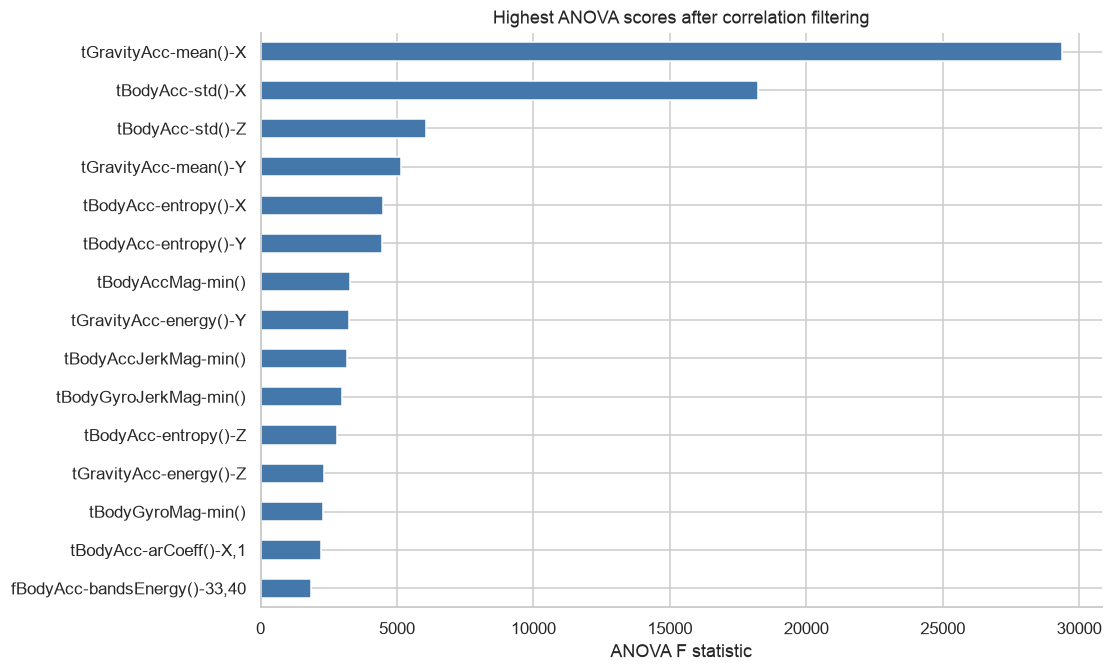

ANOVA ranking fitted to 202 correlation-filtered training features.


In [52]:
anova_diagnostic = SelectKBest(f_classif, k=50).fit(X_eda_scaled, y_train)
feature_scores = pd.Series(anova_diagnostic.scores_, index=retained_features).sort_values()
fig, ax = plt.subplots(figsize=(10, 6), layout="constrained")
feature_scores.tail(15).plot.barh(ax=ax, color="#4477AA")
ax.set(
    title="Highest ANOVA scores after correlation filtering", xlabel="ANOVA F statistic", ylabel=""
)
plt.show()
print(f"ANOVA ranking fitted to {len(retained_features)} correlation-filtered training features.")


Higher F-scores indicate stronger one-feature separation between activities. Gravity and body-acceleration measurements dominate the ranking. Validation determines whether retaining 20 or 50 features helps prediction.

In [53]:
cache_dir = TemporaryDirectory(prefix="har-cv-")
memory = Memory(cache_dir.name, verbose=0)

pipeline = Pipeline(
    [
        ("correlation", CorrelationFilter(threshold=0.90)),
        ("scale", StandardScaler()),
        ("reduce", "passthrough"),
        ("model", LogisticRegression()),
    ],
    memory=memory,
)

preprocessing_options = [
    {"reduce": ["passthrough"]},
    {"reduce": [SelectKBest(f_classif)], "reduce__k": [20, 50]},
    {"reduce": [PCA(svd_solver="full")], "reduce__n_components": [0.90, 0.95]},
]
scoring = {"macro_f1": "f1_macro", "accuracy": "accuracy"}


In [54]:
# Add the same preprocessing options to each model's parameter grid.
def parameter_grid(model_options):
    grid = []
    for preprocessing in preprocessing_options:
        for model_parameters in model_options:
            settings = preprocessing.copy()
            settings.update(model_parameters)
            grid.append(settings)
    return grid


def representation_name(params):
    if isinstance(params["reduce"], str):
        return "Correlation only"
    if isinstance(params["reduce"], SelectKBest):
        return f"KBest-{params['reduce__k']}"
    return f"PCA-{params['reduce__n_components']:.0%}"


<a id="4-classical-model-selection"></a>

## 4. Classical model selection

### 4.1. Majority-class baseline

The baseline always predicts the most common training activity. It provides a minimum reference without using sensor features.

In [55]:
from sklearn.model_selection import cross_validate

baseline = cross_validate(
    DummyClassifier(strategy="most_frequent"),
    X_train,
    y_train,
    cv=cv_splits,
    scoring={"macro_f1": "f1_macro", "accuracy": "accuracy"},
)
print(f"Baseline grouped-CV macro-F1: {baseline['test_macro_f1'].mean():.3f}")
print(f"Baseline grouped-CV accuracy: {baseline['test_accuracy'].mean():.3f}")


Baseline grouped-CV macro-F1: 0.053
Baseline grouped-CV accuracy: 0.191


The majority baseline reaches 0.053 macro-F1 and 0.191 accuracy in grouped validation. The fitted models should clearly exceed this reference.

### 4.2. Logistic regression

Multinomial logistic regression converts linear class scores into probabilities. Standardization places features on comparable scales, and L2 regularization limits coefficient size. The search tunes $C$, the inverse regularization strength; smaller values apply stronger shrinkage.

In [56]:
lr_pipeline = clone(pipeline).set_params(
    model=LogisticRegression(solver="lbfgs", max_iter=4000, random_state=SEED)
)
lr_grid = parameter_grid([{"model__C": [0.1, 1.0, 10.0]}])
lr_search = GridSearchCV(
    lr_pipeline,
    lr_grid,
    scoring=scoring,
    refit="macro_f1",
    cv=cv_splits,
    return_train_score=True,
    n_jobs=2,
    error_score="raise",
    verbose=1,
)
lr_search.fit(X_train, y_train)
print("Best parameters:", lr_search.best_params_)
print(f"CV macro-F1: {lr_search.best_score_:.4f}")


Fitting 5 folds for each of 15 candidates, totalling 75 fits
Best parameters: {'model__C': 1.0, 'reduce': 'passthrough'}
CV macro-F1: 0.9340


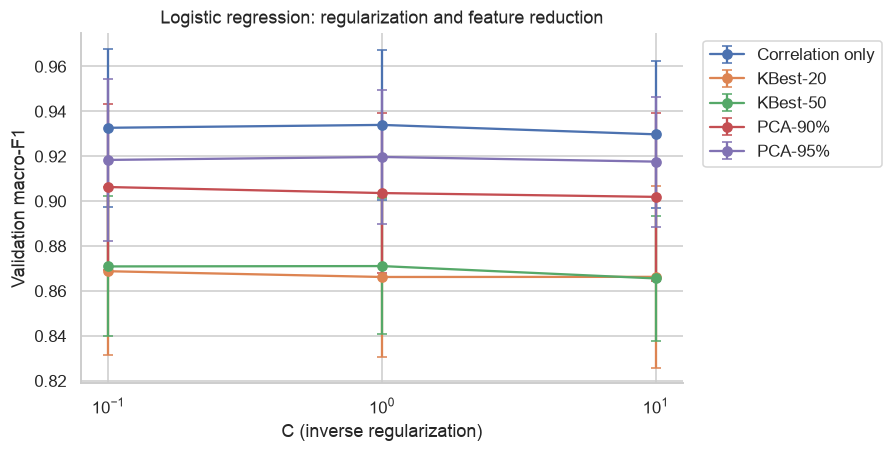

In [57]:
lr_results = pd.DataFrame(lr_search.cv_results_)
lr_results["Representation"] = lr_results["params"].map(representation_name)
lr_results["C"] = lr_results["params"].map(lambda p: p["model__C"])

fig, ax = plt.subplots(figsize=(8, 4), layout="constrained")
for name, rows in lr_results.groupby("Representation", sort=False):
    rows = rows.sort_values("C")
    ax.errorbar(
        rows["C"],
        rows["mean_test_macro_f1"],
        yerr=rows["std_test_macro_f1"],
        marker="o",
        capsize=3,
        label=name,
    )
ax.set(
    xscale="log",
    xlabel="C (inverse regularization)",
    ylabel="Validation macro-F1",
    title="Logistic regression: regularization and feature reduction",
)
ax.legend(bbox_to_anchor=(1.02, 1))
plt.show()


Correlation-filtered features with $C=1$ give the best logistic-regression score, 0.9340 macro-F1. KBest and PCA do not improve it in this search. Error bars show fold standard deviations.

### 4.3. Random forest

Random forests combine decision trees to model nonlinear relationships and feature interactions. Maximum depth and minimum leaf size control complexity. The search fixes the ensemble at 100 trees and tunes these two parameters.

In [58]:
rf_pipeline = clone(pipeline).set_params(
    model=RandomForestClassifier(n_estimators=100, random_state=SEED, n_jobs=1)
)
rf_grid = parameter_grid([{"model__max_depth": [15, None], "model__min_samples_leaf": [1, 3]}])
rf_search = GridSearchCV(
    rf_pipeline,
    rf_grid,
    scoring=scoring,
    refit="macro_f1",
    cv=cv_splits,
    return_train_score=True,
    n_jobs=2,
    error_score="raise",
    verbose=1,
)
rf_search.fit(X_train, y_train)
print("Best parameters:", rf_search.best_params_)
print(f"CV macro-F1: {rf_search.best_score_:.4f}")


Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best parameters: {'model__max_depth': 15, 'model__min_samples_leaf': 3, 'reduce': 'passthrough'}
CV macro-F1: 0.9130


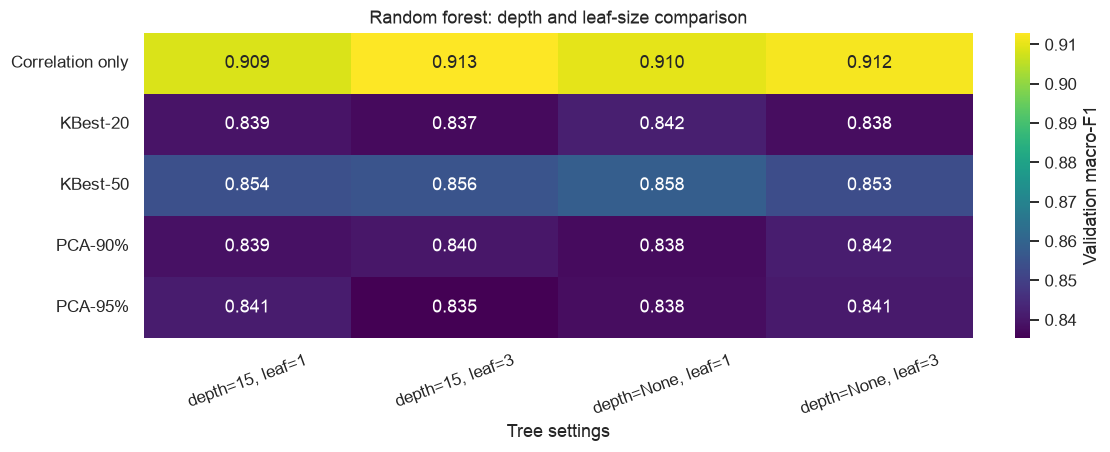

In [59]:
rf_results = pd.DataFrame(rf_search.cv_results_)
rf_results["Representation"] = rf_results["params"].map(representation_name)
rf_results["Setting"] = rf_results["params"].map(
    lambda p: f"depth={p['model__max_depth']}, leaf={p['model__min_samples_leaf']}"
)
rf_scores = rf_results.pivot(index="Representation", columns="Setting", values="mean_test_macro_f1")

fig, ax = plt.subplots(figsize=(10, 4), layout="constrained")
sns.heatmap(
    rf_scores,
    annot=True,
    fmt=".3f",
    cmap="viridis",
    ax=ax,
    cbar_kws={"label": "Validation macro-F1"},
)
ax.set(title="Random forest: depth and leaf-size comparison", xlabel="Tree settings", ylabel="")
ax.tick_params(axis="x", rotation=20)
plt.show()


The best forest uses correlation-filtered features, depth 15 and at least three samples per leaf. Its macro-F1 of 0.9130 is below logistic regression on the same participant folds.

### 4.4. Support vector machines

A linear SVM finds a wide separating margin in the engineered feature space. The RBF kernel allows nonlinear boundaries through

$$K(x, x') = \exp(-\gamma \lVert x-x'\rVert^2).$$

$C$ controls the penalty for margin violations. For the RBF kernel, $\gamma$ controls how local each observation's influence is. Both parameters are tuned together.

In [60]:
C_VALUES = [0.1, 1.0, 10.0]
GAMMA_VALUES = [0.001, 0.01, 0.1]
svm_pipeline = clone(pipeline).set_params(model=SVC(cache_size=512))
svm_grid = parameter_grid(
    [
        {"model__kernel": ["linear"], "model__C": C_VALUES},
        {"model__kernel": ["rbf"], "model__C": C_VALUES, "model__gamma": GAMMA_VALUES},
    ]
)
svm_search = GridSearchCV(
    svm_pipeline,
    svm_grid,
    scoring=scoring,
    refit="macro_f1",
    cv=cv_splits,
    return_train_score=True,
    n_jobs=2,
    error_score="raise",
    verbose=1,
)
svm_search.fit(X_train, y_train)
print("Best parameters:", svm_search.best_params_)
print(f"CV macro-F1: {svm_search.best_score_:.4f}")


Fitting 5 folds for each of 60 candidates, totalling 300 fits
Best parameters: {'model__C': 0.1, 'model__kernel': 'linear', 'reduce': 'passthrough'}
CV macro-F1: 0.9346


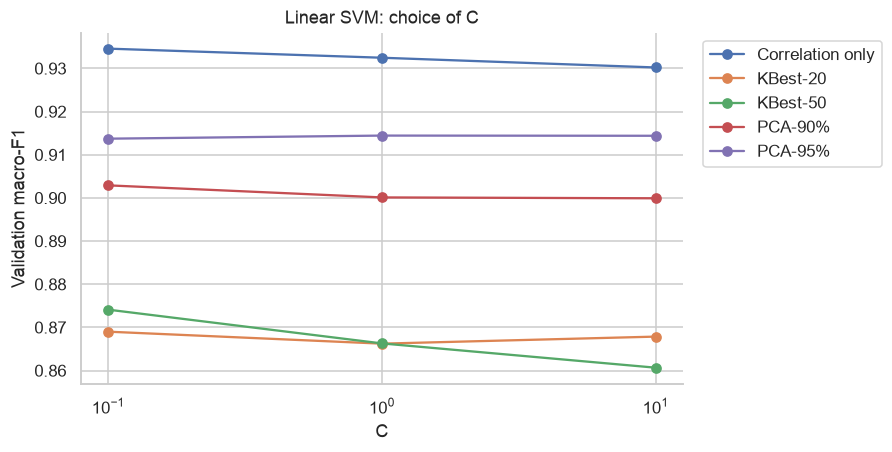

In [61]:
svm_results = pd.DataFrame(svm_search.cv_results_)
svm_results["Representation"] = svm_results["params"].map(representation_name)
svm_results["Kernel"] = svm_results["params"].map(lambda p: p["model__kernel"])
svm_results["C"] = svm_results["params"].map(lambda p: p["model__C"])
linear_results = svm_results[svm_results["Kernel"] == "linear"]

fig, ax = plt.subplots(figsize=(8, 4), layout="constrained")
for name, rows in linear_results.groupby("Representation", sort=False):
    rows = rows.sort_values("C")
    ax.plot(rows["C"], rows["mean_test_macro_f1"], marker="o", label=name)
ax.set(xscale="log", xlabel="C", ylabel="Validation macro-F1", title="Linear SVM: choice of C")
ax.legend(bbox_to_anchor=(1.02, 1))
plt.show()


The best SVM is linear with $C=0.1$ and correlation-filtered features. Its macro-F1 is 0.9346, only slightly above logistic regression.

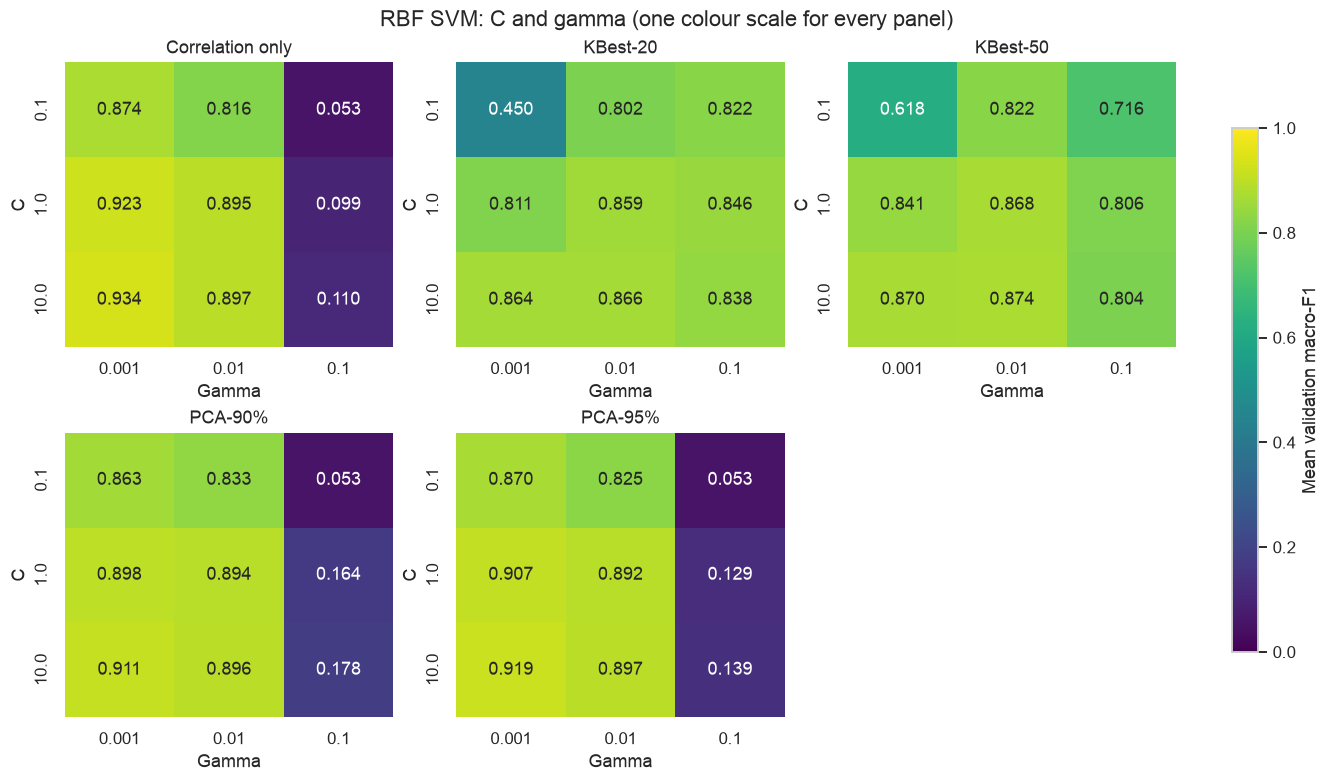

In [62]:
rbf_table = svm_results[svm_results["Kernel"] == "rbf"].copy()
rbf_table["gamma"] = rbf_table["params"].map(lambda p: p["model__gamma"])
rep_names = list(rbf_table["Representation"].unique())

fig, axes = plt.subplots(2, 3, figsize=(12, 7), layout="constrained")
for ax, name in zip(axes.flat, rep_names):
    rows = rbf_table[rbf_table["Representation"] == name]
    scores = rows.pivot(index="C", columns="gamma", values="mean_test_macro_f1")
    sns.heatmap(scores, annot=True, fmt=".3f", cmap="viridis", vmin=0, vmax=1, cbar=False, ax=ax)
    ax.set(title=name, xlabel="Gamma", ylabel="C")
axes.flat[-1].axis("off")
fig.colorbar(
    axes.flat[0].collections[0], ax=list(axes.flat), label="Mean validation macro-F1", shrink=0.8
)
fig.suptitle("RBF SVM: C and gamma (one colour scale for every panel)")
plt.show()


Small gamma values work best with the correlation-filtered representation. Gamma is scale-dependent, so the same value behaves differently after KBest or PCA.

#### RBF parameter selection

RBF settings are selected from grouped cross-validation without using test scores. The table lists the five strongest candidates.

In [63]:
rbf_ranked = rbf_table.sort_values("mean_test_macro_f1", ascending=False)
display(
    rbf_ranked[
        [
            "Representation",
            "C",
            "gamma",
            "mean_test_macro_f1",
            "std_test_macro_f1",
            "mean_test_accuracy",
        ]
    ]
    .head()
    .round(4)
)

best_rbf_row = rbf_ranked.iloc[0]
best_rbf_params = best_rbf_row["params"]
best_rbf_c = best_rbf_params["model__C"]
best_rbf_gamma = best_rbf_params["model__gamma"]

rbf_model = clone(svm_pipeline).set_params(**best_rbf_params)
rbf_model.fit(X_train, y_train)
print("RBF representation:", best_rbf_row["Representation"])
print(f"Selected C = {best_rbf_c:g}, gamma = {best_rbf_gamma:g}")
print(f"Grouped-CV macro-F1 = {best_rbf_row['mean_test_macro_f1']:.4f}")


,Representation,C,gamma,mean_test_macro_f1,std_test_macro_f1,mean_test_accuracy
9,Correlation only,10.0,0.001,0.9345,0.0281,0.9351
6,Correlation only,1.0,0.001,0.9226,0.0326,0.9236
55,PCA-95%,10.0,0.001,0.9195,0.0346,0.9193
54,PCA-90%,10.0,0.001,0.9106,0.0397,0.9098
49,PCA-95%,1.0,0.001,0.9072,0.0373,0.9076


RBF representation: Correlation only
Selected C = 10, gamma = 0.001
Grouped-CV macro-F1 = 0.9345


The best tested RBF setting uses correlation-filtered features with $C=10$ and $\gamma=0.001$, reaching 0.9345 macro-F1. Both values lie at the edge of the grid, so they are not claimed as global optima. The following curves vary one parameter while holding the other fixed; shading shows fold standard deviations.

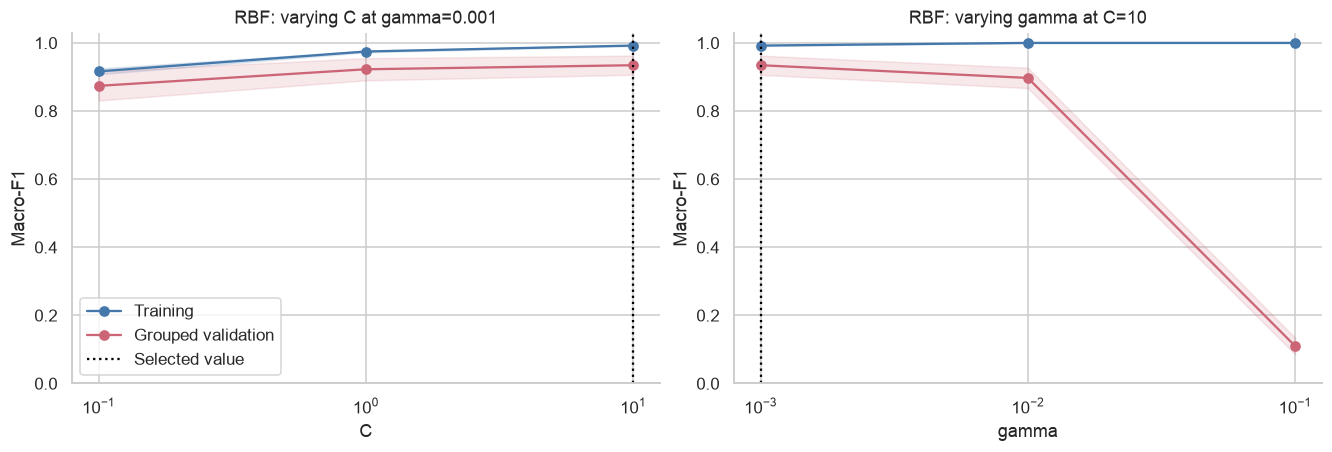

In [64]:
selected_rbf_results = rbf_table[rbf_table["Representation"] == best_rbf_row["Representation"]]
curves = [
    selected_rbf_results[selected_rbf_results["gamma"] == best_rbf_gamma].sort_values("C"),
    selected_rbf_results[selected_rbf_results["C"] == best_rbf_c].sort_values("gamma"),
]
fig, axes = plt.subplots(1, 2, figsize=(12, 4), layout="constrained")
for ax, rows, parameter, selected in zip(
    axes, curves, ["C", "gamma"], [best_rbf_c, best_rbf_gamma]
):
    x = rows[parameter].to_numpy(dtype=float)
    for split, label, color in [
        ("train", "Training", "#4477AA"),
        ("test", "Grouped validation", "#CC6677"),
    ]:
        mean = rows[f"mean_{split}_macro_f1"].to_numpy()
        std = rows[f"std_{split}_macro_f1"].to_numpy()
        ax.semilogx(x, mean, marker="o", color=color, label=label)
        ax.fill_between(x, mean - std, mean + std, color=color, alpha=0.15)
    ax.axvline(selected, color="black", linestyle=":", label="Selected value")
    ax.set(xlabel=parameter, ylabel="Macro-F1", ylim=(0, 1.03))
axes[0].set_title(f"RBF: varying C at gamma={best_rbf_gamma:g}")
axes[1].set_title(f"RBF: varying gamma at C={best_rbf_c:g}")
axes[0].legend(loc="lower left")
plt.show()


At $\gamma=0.001$, validation performance improves as $C$ increases across the tested range. At $C=10$, larger gamma creates a wider training-validation gap.

#### RBF decision slices across C and gamma

The panels are two-dimensional slices through full-feature RBF models fitted on the first grouped fold. PCA defines the viewing plane after correlation filtering. Coordinates outside the plane are fixed at their training means.

Projected validation points retain their true higher-dimensional coordinates, so a point can appear over a region different from its full-model prediction. The plot illustrates boundary geometry; grouped cross-validation selects the parameters.

In [65]:
fit_idx, val_idx = cv_splits[0]
slice_preprocessing = clone(rbf_model[:-1])
slice_preprocessing.memory = None
X_slice_train = slice_preprocessing.fit_transform(X_train.iloc[fit_idx], y_train[fit_idx])
X_slice_valid = slice_preprocessing.transform(X_train.iloc[val_idx])

slice_pca = PCA(n_components=2, svd_solver="full")
Z_slice_train = slice_pca.fit_transform(X_slice_train)
Z_slice_valid = slice_pca.transform(X_slice_valid)

# Plot limits come only from training coordinates; no rows are removed from fitting.
low = np.quantile(Z_slice_train, 0.005, axis=0) - 1
high = np.quantile(Z_slice_train, 0.995, axis=0) + 1
xx, yy = np.meshgrid(np.linspace(low[0], high[0], 90), np.linspace(low[1], high[1], 90))
slice_coordinates = np.c_[xx.ravel(), yy.ravel()]
slice_features = slice_pca.inverse_transform(slice_coordinates)
activity_codes = {activity: i for i, activity in enumerate(ACTIVITIES)}


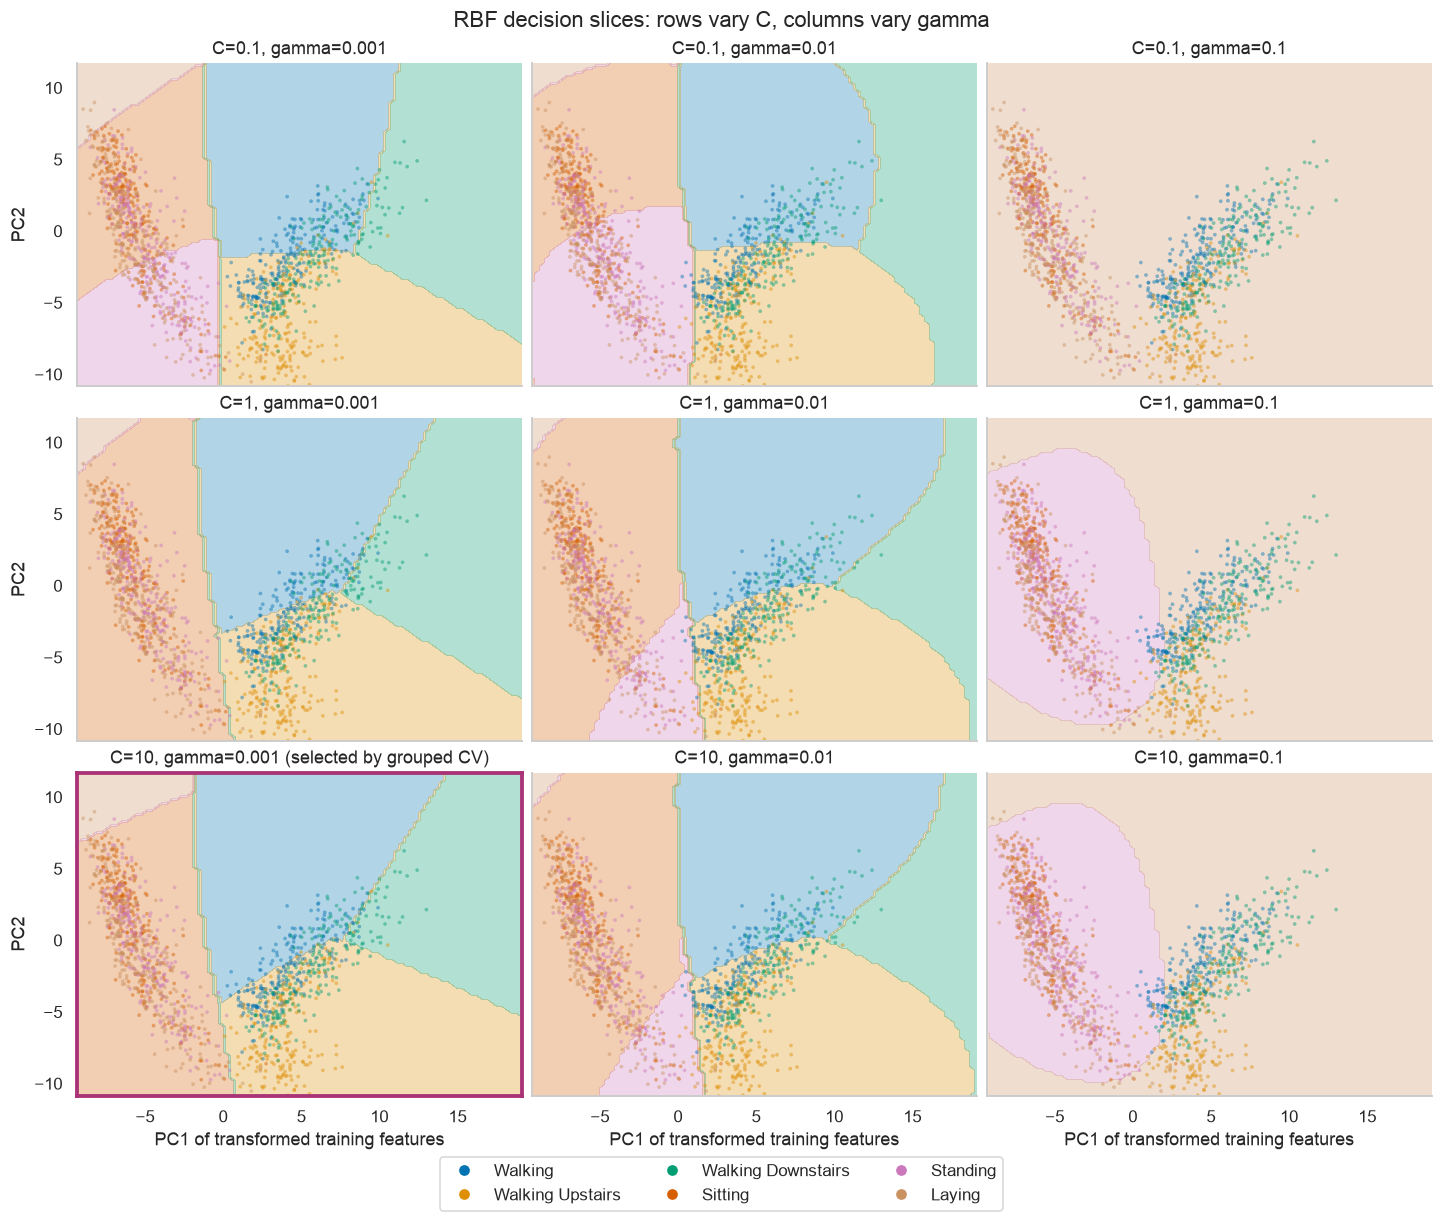

In [66]:
from matplotlib.colors import ListedColormap
from matplotlib.lines import Line2D

colors = [activity_colors[a] for a in ACTIVITIES]
cmap = ListedColormap(colors)
fig, axes = plt.subplots(
    len(C_VALUES),
    len(GAMMA_VALUES),
    figsize=(13, 11),
    sharex=True,
    sharey=True,
    layout="constrained",
)
for row, c_value in enumerate(C_VALUES):
    for column, gamma_value in enumerate(GAMMA_VALUES):
        ax = axes[row, column]
        model = SVC(kernel="rbf", C=c_value, gamma=gamma_value, cache_size=512)
        model.fit(X_slice_train, y_train[fit_idx])
        prediction = model.predict(slice_features)
        regions = np.array([activity_codes[a] for a in prediction]).reshape(xx.shape)
        ax.contourf(xx, yy, regions, levels=np.arange(7) - 0.5, cmap=cmap, alpha=0.3)
        for activity in ACTIVITIES:
            mask = y_train[val_idx] == activity
            ax.scatter(
                Z_slice_valid[mask, 0],
                Z_slice_valid[mask, 1],
                s=6,
                alpha=0.45,
                color=activity_colors[activity],
                edgecolors="none",
            )
        selected = c_value == best_rbf_c and gamma_value == best_rbf_gamma
        title = f"C={c_value:g}, gamma={gamma_value:g}"
        if selected:
            title += " (selected by grouped CV)"
            for spine in ax.spines.values():
                spine.set_visible(True)
                spine.set_color("#AA3377")
                spine.set_linewidth(2.5)
        ax.set(title=title, xlim=(low[0], high[0]), ylim=(low[1], high[1]))
        ax.grid(False)
        if row == len(C_VALUES) - 1:
            ax.set_xlabel("PC1 of transformed training features")
        if column == 0:
            ax.set_ylabel("PC2")
handles = [
    Line2D([], [], marker="o", linestyle="", color=color, label=label)
    for color, label in zip(colors, activity_labels)
]
fig.legend(handles=handles, loc="outside lower center", ncol=3)
fig.suptitle("RBF decision slices: rows vary C, columns vary gamma")
plt.show()


The highlighted panel uses the selected $C$ and $\gamma$. Large gamma produces highly local predictions, leaving broad single-class regions where the mean plane is far from observed data. The figure is a slice, not the complete boundary.

### 4.5. Cross-validation comparison


In [67]:
searches = {"Logistic regression": lr_search, "Random forest": rf_search, "SVM": svm_search}
candidate_tables = []
for name, search in searches.items():
    table = pd.DataFrame(search.cv_results_)
    table["Model"] = name
    table["Representation"] = [representation_name(p) for p in table["params"]]
    candidate_tables.append(table)
candidates = pd.concat(candidate_tables, ignore_index=True)
leaderboard = candidates.sort_values("mean_test_macro_f1", ascending=False).drop_duplicates("Model")
display(
    leaderboard[
        [
            "Model",
            "Representation",
            "mean_train_macro_f1",
            "mean_test_macro_f1",
            "std_test_macro_f1",
            "mean_test_accuracy",
        ]
    ].round(4)
)


,Model,Representation,mean_train_macro_f1,mean_test_macro_f1,std_test_macro_f1,mean_test_accuracy
35,SVM,Correlation only,0.9892,0.9346,0.0250,0.9350
1,Logistic regression,Correlation only,0.9916,0.9340,0.0334,0.9339
16,Random forest,Correlation only,0.9996,0.9130,0.0380,0.9161


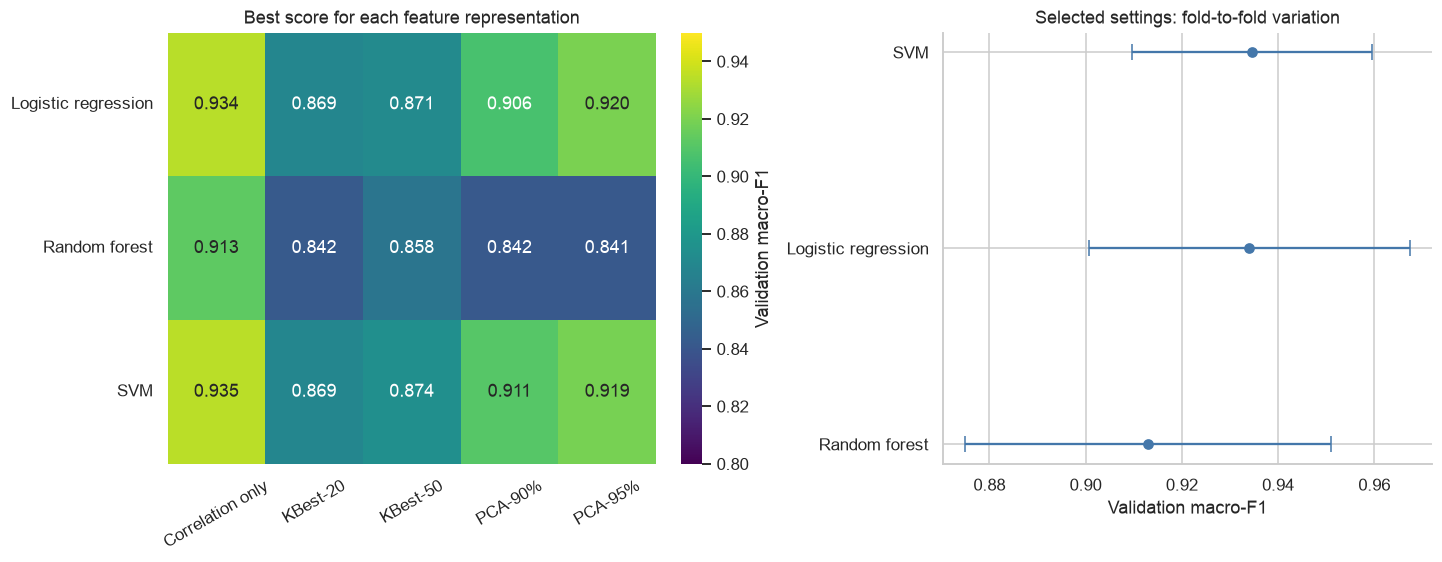

In [68]:
comparison = candidates.groupby(["Model", "Representation"])["mean_test_macro_f1"].max().unstack()
fig, axes = plt.subplots(1, 2, figsize=(13, 5), layout="constrained")
sns.heatmap(
    comparison,
    annot=True,
    fmt=".3f",
    cmap="viridis",
    vmin=0.8,
    vmax=0.95,
    ax=axes[0],
    cbar_kws={"label": "Validation macro-F1"},
)
axes[0].set(title="Best score for each feature representation", xlabel="", ylabel="")
axes[0].tick_params(axis="x", rotation=30)
axes[0].tick_params(axis="y", rotation=0)
positions = np.arange(len(leaderboard))
axes[1].errorbar(
    leaderboard["mean_test_macro_f1"],
    positions,
    xerr=leaderboard["std_test_macro_f1"],
    fmt="o",
    capsize=5,
    color="#4477AA",
)
axes[1].set_yticks(positions, leaderboard["Model"])
axes[1].invert_yaxis()
axes[1].set(title="Selected settings: fold-to-fold variation", xlabel="Validation macro-F1")
plt.show()


All three model families perform best with correlation filtering and no further reduction. Linear SVM scores 0.9346, RBF SVM 0.9345 and logistic regression 0.9340 mean macro-F1.

The predefined rule selects the highest mean, so linear SVM is retained. These differences are small relative to fold variation and do not establish a clear winner. Fold standard deviations are neither confidence intervals nor significance tests.

<a id="5-logistic-regression-interpretation"></a>

## 5. Logistic regression interpretation

The correlation-filtered logistic model scores 0.9340 grouped-validation macro-F1, close to the selected linear SVM's 0.9346. Its standardized coefficients explain associations within the logistic model, not the SVM.

In [69]:
lr_correlation = candidates[
    (candidates["Model"] == "Logistic regression")
    & (candidates["Representation"] == "Correlation only")
]
interpret_row = lr_correlation.sort_values("mean_test_macro_f1", ascending=False).iloc[0]
interpret_model = clone(lr_search.estimator).set_params(**interpret_row["params"])
interpret_model.fit(X_train, y_train)
steps = interpret_model.named_steps
selected_names = steps["correlation"].get_feature_names_out()
lr = steps["model"]


### 5.1. Coefficients, log-odds and odds ratios

For activity $c$ relative to standing,

$$\log \frac{P(Y=c\mid z)}{P(Y=\mathrm{STANDING}\mid z)}
= (b_c-b_r) + \sum_j(\beta_{cj}-\beta_{rj})z_j.$$

The features are standardized. A coefficient difference therefore describes a one-standard-deviation increase while other features are held fixed. Positive values favour activity $c$; negative values favour standing. Exponentiation gives the odds ratio $\exp(\beta_{cj}-\beta_{rj})$.

The coefficients describe fitted associations rather than causal effects. Correlation and regularization can also affect their size.

In [70]:
reference = list(lr.classes_).index("STANDING")
log_odds = pd.DataFrame(lr.coef_ - lr.coef_[reference], index=lr.classes_, columns=selected_names)
intercepts = pd.Series(
    lr.intercept_ - lr.intercept_[reference], index=lr.classes_, name="Intercept difference"
)
display(intercepts)
interpretation = (
    log_odds.drop(index="STANDING").stack().rename("Log-odds change per SD").reset_index()
)
interpretation.columns = ["Activity vs STANDING", "Feature", "Log-odds change per SD"]
interpretation["Odds ratio per SD"] = np.exp(interpretation["Log-odds change per SD"])
display(interpretation.loc[interpretation["Log-odds change per SD"].abs().nlargest(15).index])


LAYING                0.122518
SITTING               0.109984
STANDING              0.000000
WALKING               0.392488
WALKING_DOWNSTAIRS   -0.566826
WALKING_UPSTAIRS     -0.366559
Name: Intercept difference, dtype: float64

,Activity vs STANDING,Feature,Log-odds change per SD,Odds ratio per SD
226,SITTING,tGravityAcc-mean()-Y,6.729913,837.074114
24,LAYING,tGravityAcc-mean()-Y,4.923073,137.424250
630,WALKING_DOWNSTAIRS,tGravityAcc-mean()-Y,4.521922,92.012290
428,WALKING,tGravityAcc-mean()-Y,3.498320,33.059874
23,LAYING,tGravityAcc-mean()-X,-3.292585,0.037158
832,WALKING_UPSTAIRS,tGravityAcc-mean()-Y,3.003740,20.160788
31,LAYING,tGravityAcc-energy()-Z,2.884643,17.897183
30,LAYING,tGravityAcc-energy()-Y,2.821618,16.804026
264,SITTING,"tBodyGyro-arCoeff()-X,1",2.474346,11.873945
302,SITTING,tBodyGyroMag-min(),2.059971,7.845746


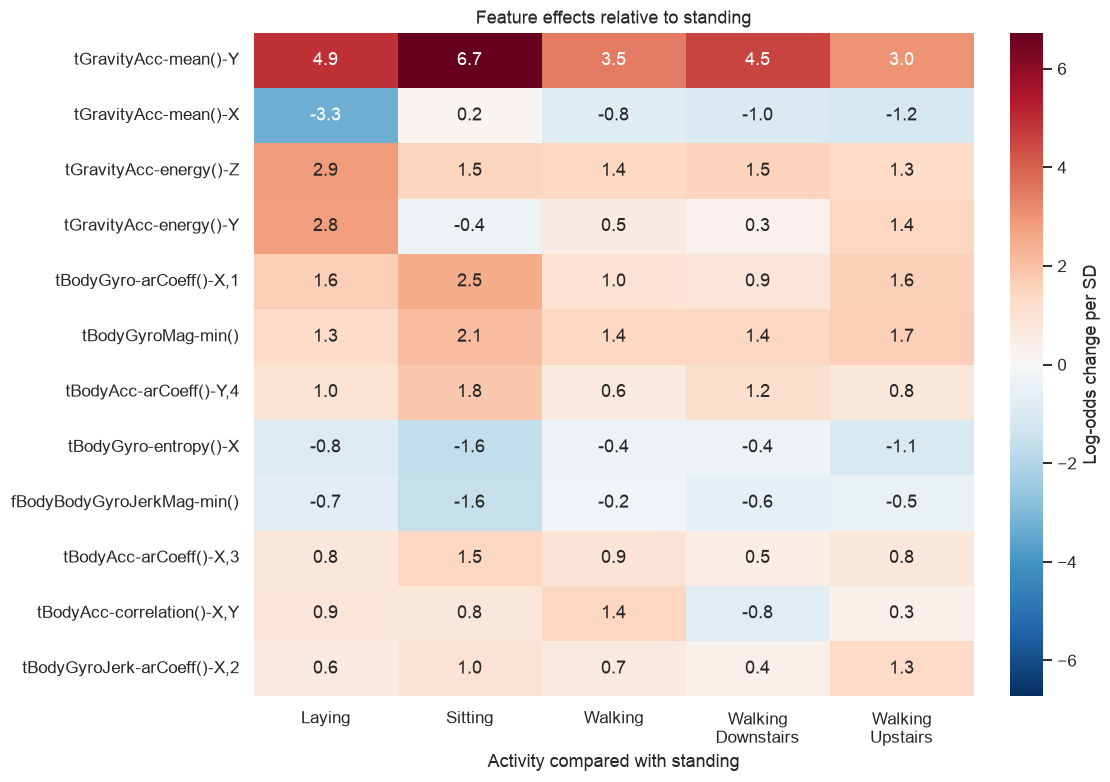

In [71]:
top_features = log_odds.abs().max().nlargest(12).index
effects = log_odds.drop(index="STANDING")[top_features].T
limit = np.abs(effects.to_numpy()).max()
fig, ax = plt.subplots(figsize=(10, 7), layout="constrained")
sns.heatmap(
    effects,
    annot=True,
    fmt=".1f",
    center=0,
    vmin=-limit,
    vmax=limit,
    cmap="RdBu_r",
    ax=ax,
    cbar_kws={"label": "Log-odds change per SD"},
)
ax.set(
    title="Feature effects relative to standing",
    xlabel="Activity compared with standing",
    ylabel="",
)
ax.set_xticklabels([label.replace("_", "\n").title() for label in effects.columns], rotation=0)
ax.tick_params(axis="y", rotation=0)
plt.show()


In [72]:
# Verify the pairwise log-odds identity numerically, without unstable probability division.
Z_interpret = interpret_model[:-1].transform(X_train.iloc[:20])
scores = lr.decision_function(Z_interpret)
manual_log_odds = Z_interpret @ (lr.coef_ - lr.coef_[reference]).T + intercepts.to_numpy()
np.testing.assert_allclose(manual_log_odds, scores - scores[:, [reference]], atol=1e-9)
largest = interpretation.loc[interpretation["Log-odds change per SD"].abs().idxmax()]
print(
    f"For {largest['Activity vs STANDING']} versus STANDING, a one-training-SD increase in "
    f"{largest['Feature']} multiplies the fitted odds ratio by {largest['Odds ratio per SD']:.3g}, "
    "holding the other retained features fixed."
)
print(
    f"Interpretation model: {interpret_row['Representation']}, "
    f"CV macro-F1 = {interpret_row['mean_test_macro_f1']:.4f}"
)


For SITTING versus STANDING, a one-training-SD increase in tGravityAcc-mean()-Y multiplies the fitted odds ratio by 837, holding the other retained features fixed.
Interpretation model: Correlation only, CV macro-F1 = 0.9340


For sitting relative to standing, `tGravityAcc-mean()-Y` has the largest displayed coefficient difference. A one-standard-deviation increase multiplies the fitted odds by about 837 when other features are fixed. This applies to odds rather than probability and should be interpreted as model evidence, not causation.

<a id="6-official-test-results"></a>

## 6. Official test results

Grouped cross-validation fixes the model settings before evaluation. The selected linear SVM is compared with the majority baseline on the nine official test participants.

In [73]:
winner_name = str(leaderboard.iloc[0]["Model"])
winner_search = searches[winner_name]
best_classical_model = winner_search.best_estimator_
print("Selected model:", winner_name)
print("Representation:", representation_name(winner_search.best_params_))
print("Parameters:", winner_search.best_params_)
print("Selection CV macro-F1:", winner_search.best_score_)
print(
    "Correlation-retained features:",
    best_classical_model.named_steps["correlation"].keep_mask_.sum(),
)
print("Classifier input dimensions:", best_classical_model.named_steps["model"].n_features_in_)


Selected model: SVM
Representation: Correlation only
Parameters: {'model__C': 0.1, 'model__kernel': 'linear', 'reduce': 'passthrough'}
Selection CV macro-F1: 0.934573385364553
Correlation-retained features: 202
Classifier input dimensions: 202


In [74]:
X_test = data["test"][FEATURES]
y_test = data["test"]["Activity"].to_numpy()
test_subjects = data["test"]["subject"].to_numpy()
assert set(groups).isdisjoint(test_subjects)
test_pred = best_classical_model.predict(X_test)
dummy = DummyClassifier(strategy="most_frequent").fit(X_train, y_train)
dummy_pred = dummy.predict(X_test)
test_summary = pd.DataFrame(
    [
        {
            "Model": name,
            "Accuracy": accuracy_score(y_test, pred),
            "Macro-F1": f1_score(y_test, pred, average="macro"),
        }
        for name, pred in [(winner_name, test_pred), ("Majority baseline", dummy_pred)]
    ]
)
display(test_summary)
print(classification_report(y_test, test_pred, labels=ACTIVITIES, digits=3, zero_division=0))


,Model,Accuracy,Macro-F1
0,SVM,0.936546,0.935438
1,Majority baseline,0.182219,0.051378


                    precision    recall  f1-score   support

           WALKING      0.899     0.986     0.940       496
  WALKING_UPSTAIRS      0.938     0.898     0.918       471
WALKING_DOWNSTAIRS      0.965     0.907     0.935       420
           SITTING      0.933     0.874     0.902       491
          STANDING      0.896     0.942     0.918       532
            LAYING      0.998     1.000     0.999       537

          accuracy                          0.937      2947
         macro avg      0.938     0.934     0.935      2947
      weighted avg      0.938     0.937     0.936      2947



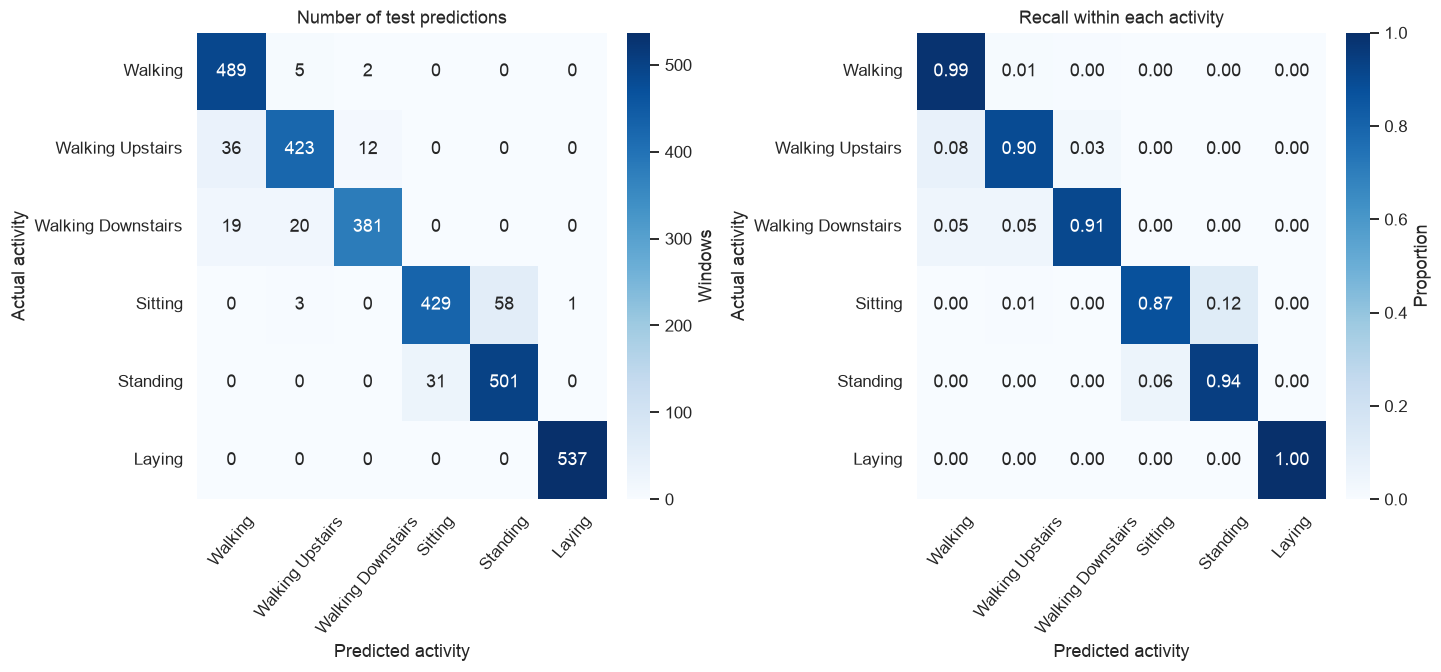

In [75]:
fig, axes = plt.subplots(1, 2, figsize=(13, 6), layout="constrained")
for ax, normalization in zip(axes, [None, "true"]):
    matrix = confusion_matrix(y_test, test_pred, labels=ACTIVITIES, normalize=normalization)
    sns.heatmap(
        matrix,
        annot=True,
        fmt="d" if normalization is None else ".2f",
        cmap="Blues",
        vmin=0,
        vmax=None if normalization is None else 1,
        xticklabels=activity_labels,
        yticklabels=activity_labels,
        ax=ax,
        cbar_kws={"label": "Windows" if normalization is None else "Proportion"},
    )
    ax.set(
        title=(
            "Number of test predictions" if normalization is None else "Recall within each activity"
        ),
        xlabel="Predicted activity",
        ylabel="Actual activity",
    )
    ax.tick_params(axis="x", rotation=50)
    ax.tick_params(axis="y", rotation=0)
plt.show()


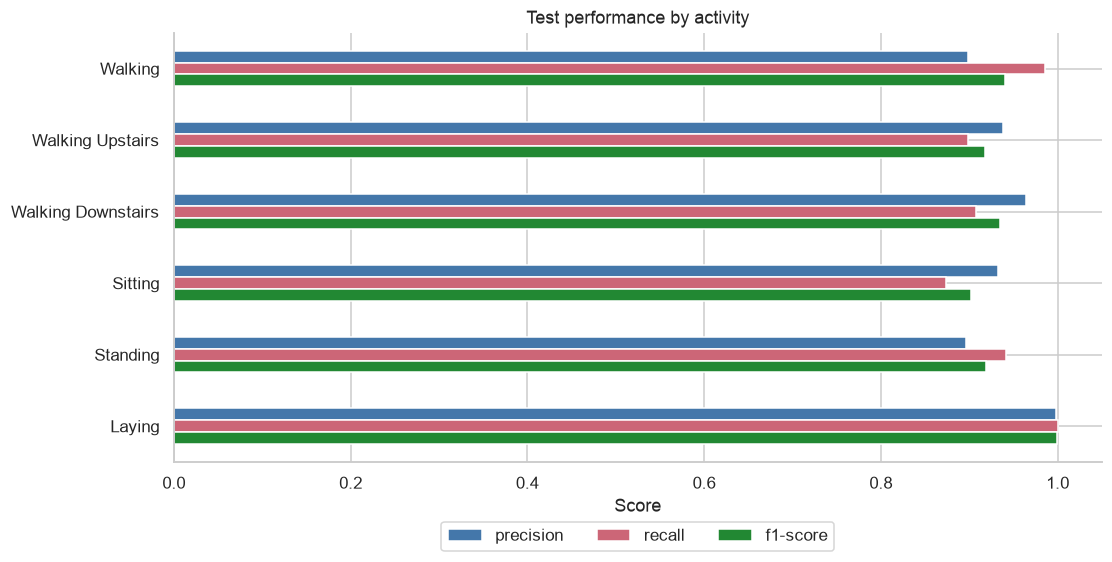

In [76]:
report = classification_report(
    y_test, test_pred, labels=ACTIVITIES, output_dict=True, zero_division=0
)
activity_metrics = pd.DataFrame(report).T.loc[ACTIVITIES, ["precision", "recall", "f1-score"]]
activity_metrics.index = activity_labels
fig, ax = plt.subplots(figsize=(10, 5), layout="constrained")
activity_metrics.plot.barh(ax=ax, color=["#4477AA", "#CC6677", "#228833"])
ax.invert_yaxis()
ax.set(title="Test performance by activity", xlabel="Score", ylabel="", xlim=(0, 1.05))
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=3)
plt.show()


The selected SVM reaches 93.65% accuracy and 0.9354 macro-F1 on 2,947 test windows. Laying has perfect recall. Sitting recall is 0.874, with 58 sitting windows predicted as standing.

,Subject,Windows,Accuracy,Macro-F1
0,2,302,0.973510,0.972619
1,4,317,0.899054,0.896013
2,9,288,0.854167,0.852520
3,10,294,0.887755,0.884015
4,12,320,0.946875,0.944694
5,13,327,0.966361,0.963822
6,18,364,0.964286,0.961021
7,20,354,0.929379,0.921809
8,24,381,0.984252,0.984986


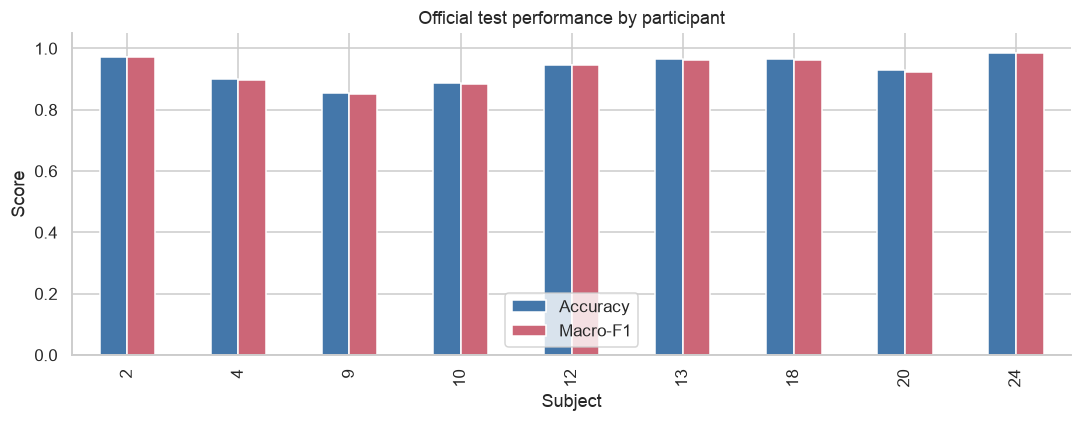

Largest directed confusion: SITTING → STANDING (58 windows).
Unweighted mean participant accuracy: 0.934


In [77]:
subject_rows = []
for subject in np.unique(test_subjects):
    mask = test_subjects == subject
    subject_rows.append(
        {
            "Subject": subject,
            "Windows": int(mask.sum()),
            "Accuracy": accuracy_score(y_test[mask], test_pred[mask]),
            "Macro-F1": f1_score(
                y_test[mask], test_pred[mask], labels=ACTIVITIES, average="macro", zero_division=0
            ),
        }
    )
subject_results = pd.DataFrame(subject_rows)
display(subject_results)
subject_results.plot.bar(
    x="Subject",
    y=["Accuracy", "Macro-F1"],
    ylim=(0, 1.05),
    figsize=(10, 4),
    color=["#4477AA", "#CC6677"],
)
plt.title("Official test performance by participant")
plt.ylabel("Score")
plt.tight_layout()
plt.show()
cm = confusion_matrix(y_test, test_pred, labels=ACTIVITIES)
off_diagonal = cm.copy()
np.fill_diagonal(off_diagonal, 0)
i, j = np.unravel_index(off_diagonal.argmax(), off_diagonal.shape)
print(
    f"Largest directed confusion: {ACTIVITIES[i]} → {ACTIVITIES[j]} ({off_diagonal[i, j]} windows)."
)
print(f"Unweighted mean participant accuracy: {subject_results['Accuracy'].mean():.3f}")


Participant accuracy ranges from 85.42% to 98.43%. This variation is hidden by the pooled score. Because windows overlap, uncertainty is assessed by resampling participants rather than individual windows.

### 6.1. RBF SVM

The RBF parameters were fixed by grouped validation. The following results use the same nine test participants as the selected linear SVM and do not alter model selection.

In [78]:
rbf_test_pred = rbf_model.predict(X_test)
rbf_test_result = pd.DataFrame(
    [
        {
            "Model": f"RBF SVM (C={best_rbf_c:g}, gamma={best_rbf_gamma:g})",
            "Accuracy": accuracy_score(y_test, rbf_test_pred),
            "Macro-F1": f1_score(y_test, rbf_test_pred, average="macro"),
        }
    ]
)
display(pd.concat([test_summary.iloc[[0]], rbf_test_result], ignore_index=True).round(4))

print(f"RBF test accuracy: {rbf_test_result.iloc[0]['Accuracy']:.2%}")
print(f"RBF test macro-F1: {rbf_test_result.iloc[0]['Macro-F1']:.4f}")
rbf_model.memory = None


,Model,Accuracy,Macro-F1
0,SVM,0.9365,0.9354
1,"RBF SVM (C=10, gamma=0.001)",0.9447,0.9438


RBF test accuracy: 94.47%
RBF test macro-F1: 0.9438


,Linear SVM recall,RBF SVM recall
Walking,0.986,0.992
Walking Upstairs,0.898,0.913
Walking Downstairs,0.907,0.929
Sitting,0.874,0.888
Standing,0.942,0.938
Laying,1.000,1.000


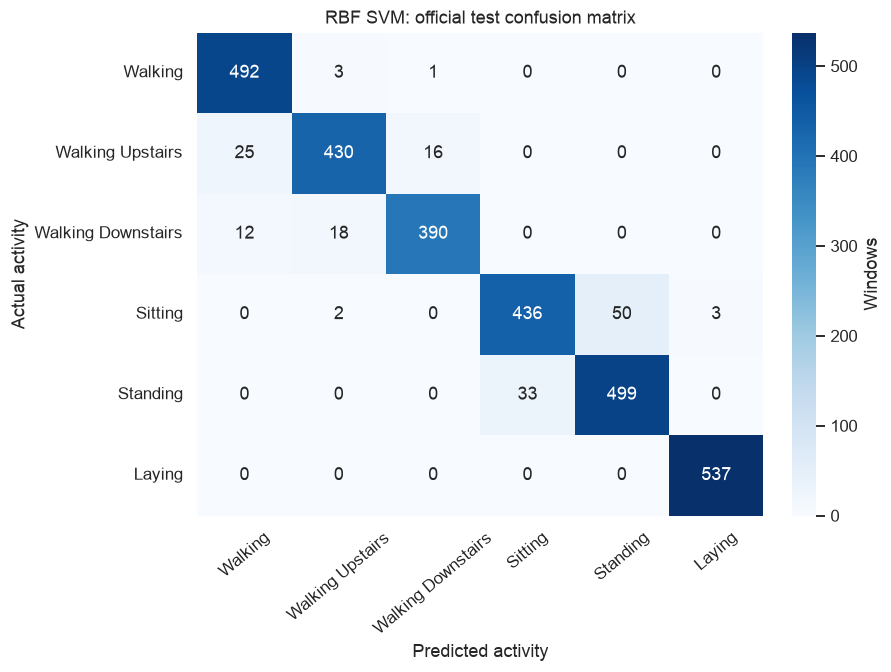

In [79]:
rbf_report = classification_report(
    y_test, rbf_test_pred, labels=ACTIVITIES, output_dict=True, zero_division=0
)
recall_comparison = pd.DataFrame(
    {
        "Linear SVM recall": [report[a]["recall"] for a in ACTIVITIES],
        "RBF SVM recall": [rbf_report[a]["recall"] for a in ACTIVITIES],
    },
    index=activity_labels,
)
display(recall_comparison.style.format("{:.3f}"))
rbf_cm = confusion_matrix(y_test, rbf_test_pred, labels=ACTIVITIES)
fig, ax = plt.subplots(figsize=(8, 6), layout="constrained")
sns.heatmap(
    rbf_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    ax=ax,
    xticklabels=activity_labels,
    yticklabels=activity_labels,
    cbar_kws={"label": "Windows"},
)
ax.set(
    title="RBF SVM: official test confusion matrix",
    xlabel="Predicted activity",
    ylabel="Actual activity",
)
ax.tick_params(axis="x", rotation=40)
ax.tick_params(axis="y", rotation=0)
plt.show()


RBF SVM reaches 94.47% accuracy and 0.9438 macro-F1. Its higher observed test score does not replace the validation-based selection rule or establish improvement outside this dataset.

### 6.2. Logistic regression on the official test participants

The interpreted logistic model is refitted on all 21 training participants with $C=1$, then evaluated without further tuning.

,Model,Accuracy,Macro-F1
0,Linear SVM (CV selection),93.65%,0.9354
1,RBF SVM,94.47%,0.9438
2,Logistic regression,94.47%,0.9446


,precision,recall,f1-score,support
WALKING,0.940,0.988,0.964,496.000
WALKING_UPSTAIRS,0.955,0.936,0.945,471.000
WALKING_DOWNSTAIRS,0.973,0.938,0.955,420.000
SITTING,0.940,0.864,0.900,491.000
STANDING,0.877,0.949,0.912,532.000
LAYING,0.996,0.987,0.992,537.000
accuracy,0.945,0.945,0.945,0.945
macro avg,0.947,0.944,0.945,2947.000
weighted avg,0.946,0.945,0.945,2947.000


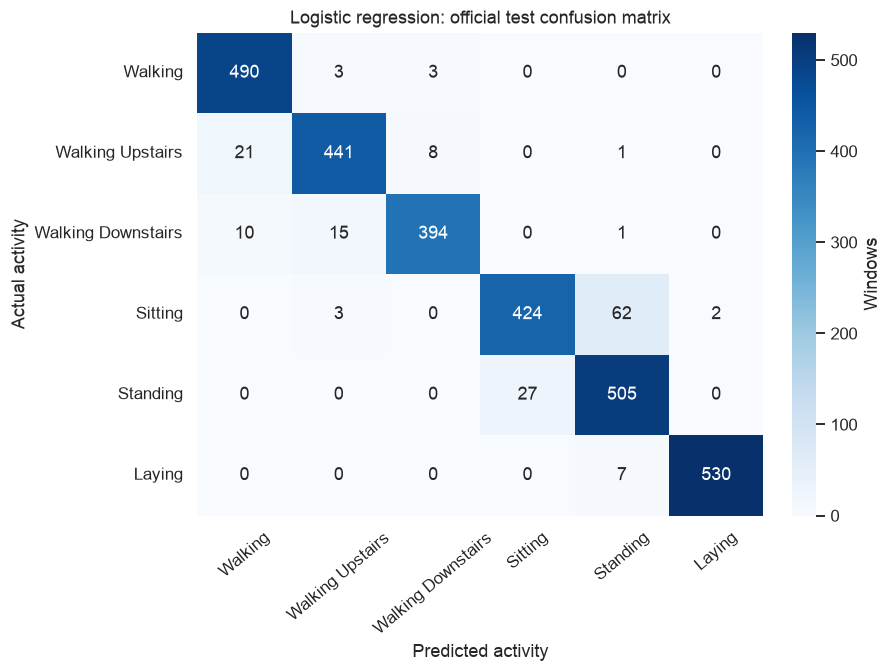

Logistic regression test accuracy: 94.47%
Logistic regression test macro-F1: 0.9446
Largest directed confusion: SITTING predicted as STANDING (62 windows).


In [80]:
logistic_test_pred = interpret_model.predict(X_test)
logistic_report = classification_report(
    y_test, logistic_test_pred, labels=ACTIVITIES, output_dict=True, zero_division=0
)
classical_test_comparison = pd.DataFrame([
    {"Model": name, "Accuracy": accuracy_score(y_test, prediction),
     "Macro-F1": f1_score(y_test, prediction, average="macro")}
    for name, prediction in [
        ("Linear SVM (CV selection)", test_pred),
        ("RBF SVM", rbf_test_pred),
        ("Logistic regression", logistic_test_pred),
    ]
])
display(classical_test_comparison.style.format({"Accuracy": "{:.2%}", "Macro-F1": "{:.4f}"}))
display(pd.DataFrame(logistic_report).T.round(3))
logistic_cm = confusion_matrix(y_test, logistic_test_pred, labels=ACTIVITIES)
fig, ax = plt.subplots(figsize=(8, 6), layout="constrained")
sns.heatmap(logistic_cm, annot=True, fmt="d", cmap="Blues", ax=ax,
            xticklabels=activity_labels, yticklabels=activity_labels,
            cbar_kws={"label": "Windows"})
ax.set(title="Logistic regression: official test confusion matrix",
       xlabel="Predicted activity", ylabel="Actual activity")
ax.tick_params(axis="x", rotation=40)
ax.tick_params(axis="y", rotation=0)
plt.show()
errors = logistic_cm.copy()
np.fill_diagonal(errors, 0)
actual_index, predicted_index = np.unravel_index(errors.argmax(), errors.shape)
print(f"Logistic regression test accuracy: {accuracy_score(y_test, logistic_test_pred):.2%}")
print(f"Logistic regression test macro-F1: {f1_score(y_test, logistic_test_pred, average='macro'):.4f}")
if errors.max() > 0:
    print(f"Largest directed confusion: {ACTIVITIES[actual_index]} predicted as "
          f"{ACTIVITIES[predicted_index]} ({errors.max()} windows).")


Logistic regression reaches 94.47% accuracy and 0.9446 macro-F1. Its confusion matrix provides the test error pattern for the model interpreted above.

In [81]:
for search in searches.values():
    search.best_estimator_.memory = None
interpret_model.memory = None
cache_dir.cleanup()


### 6.3. Saved evaluation and participant uncertainty

The saved artifact records folds, settings, predictions and source fingerprints. Bootstrap intervals resample all nine test participants with replacement while retaining every window from each sampled person. The 2.5th and 97.5th percentiles form the reported 95% interval.

These intervals describe participant sampling uncertainty for each fixed model. They exclude retraining and model-selection variation, and overlap alone is not a test of model differences.

In [82]:
import json
from har_pipeline import find_data_file
from har_evaluation import evaluate_by_subject, run_provenance

ARTIFACTS = ROOT / "artifacts"
ARTIFACTS.mkdir(exist_ok=True)
classical_metrics = evaluate_by_subject(y_test, test_pred, test_subjects, ACTIVITIES, seed=SEED)
classical_metrics.update(
    {
        "name": winner_name,
        "representation": representation_name(winner_search.best_params_),
        "params": {k: v for k, v in winner_search.best_params_.items() if k.startswith("model__")},
        "cv_macro_f1": float(winner_search.best_score_),
        "features": int(best_classical_model.named_steps["model"].n_features_in_),
    }
)
har_metrics = {
    "schema_version": 2,
    "provenance": run_provenance(ROOT, "HAR.ipynb", find_data_file(), SEED),
    "training_subjects": len(np.unique(groups)),
    "test_subjects": len(np.unique(test_subjects)),
    "selection_metric": "mean grouped-CV macro-F1",
    "classical": classical_metrics,
    "logistic": {
        **evaluate_by_subject(y_test, logistic_test_pred, test_subjects, ACTIVITIES, seed=SEED),
        "name": "Logistic regression",
        "representation": "Correlation only",
        "params": {k: v for k, v in interpret_row["params"].items() if k.startswith("model__")},
        "cv_macro_f1": float(interpret_row["mean_test_macro_f1"]),
        "features": int(interpret_model.named_steps["model"].n_features_in_),
    },
    "rbf_followup": {
        **evaluate_by_subject(y_test, rbf_test_pred, test_subjects, ACTIVITIES, seed=SEED),
        "name": "RBF SVM",
        "representation": best_rbf_row["Representation"],
        "params": {k: v for k, v in best_rbf_params.items() if k.startswith("model__")},
        "cv_macro_f1": float(best_rbf_row["mean_test_macro_f1"]),
    },
    "folds": [
        {
            "fold": i + 1,
            "fit_subjects": np.unique(groups[tr]).tolist(),
            "validation_subjects": np.unique(groups[va]).tolist(),
        }
        for i, (tr, va) in enumerate(cv_splits)
    ],
    "cv_results": [
        {
            "model": row["Model"],
            "representation": row["Representation"],
            "params": {k: v for k, v in row["params"].items() if k != "reduce"},
            "mean_macro_f1": float(row["mean_test_macro_f1"]),
            "std_macro_f1": float(row["std_test_macro_f1"]),
            "fold_macro_f1": [float(row[f"split{i}_test_macro_f1"]) for i in range(len(cv_splits))],
        }
        for _, row in candidates.iterrows()
    ],
}
(ARTIFACTS / "har_results.json").write_text(
    json.dumps(har_metrics, indent=2, allow_nan=False) + "\n"
)
pd.DataFrame(
    {
        "row": np.arange(len(y_test)),
        "subject": test_subjects,
        "actual": y_test,
        "selected_prediction": test_pred,
        "rbf_prediction": rbf_test_pred,
        "logistic_prediction": logistic_test_pred,
        "baseline_prediction": dummy_pred,
    }
).to_csv(ARTIFACTS / "har_predictions.csv", index=False)
interval_rows = []
for name, metrics in [
    ("Selected linear SVM", classical_metrics),
    ("RBF SVM", har_metrics["rbf_followup"]),
    ("Logistic regression", har_metrics["logistic"]),
]:
    for metric, bounds in metrics["subject_bootstrap_95_percentile"].items():
        interval_rows.append(
            {
                "Model": name,
                "Metric": metric,
                "Estimate": metrics[metric],
                "95% lower": bounds[0],
                "95% upper": bounds[1],
            }
        )
display(
    pd.DataFrame(interval_rows).style.format(
        {"Estimate": "{:.4f}", "95% lower": "{:.4f}", "95% upper": "{:.4f}"}
    )
)
print("Saved current classical results and predictions.")


,Model,Metric,Estimate,95% lower,95% upper
0,Selected linear SVM,accuracy,0.9365,0.9062,0.9607
1,Selected linear SVM,macro_f1,0.9354,0.9046,0.9596
2,RBF SVM,accuracy,0.9447,0.9130,0.9684
3,RBF SVM,macro_f1,0.9438,0.9114,0.9672
4,Logistic regression,accuracy,0.9447,0.9102,0.9700
5,Logistic regression,macro_f1,0.9446,0.9104,0.9693


Saved current classical results and predictions.


<a id="7-discussion-and-limitations"></a>

## 7. Discussion and limitations

Correlation filtering reduces 561 engineered features to 202. Linear SVM, RBF SVM and logistic regression have nearly identical grouped-validation macro-F1 scores, so linear SVM is selected by the predefined highest-mean rule rather than a clear performance advantage.

On the test participants, linear SVM reaches 93.65% accuracy, while RBF SVM and logistic regression both reach 94.47%. Sitting and standing remain the main confusion, and performance varies across people. In daily activity monitoring, these errors could lead to incorrect estimates of sitting and standing time. The controlled waist-mounted recordings therefore provide a benchmark, while use with phones carried in other positions still needs evaluation.

Limitations:

- Only nine test participants are available, producing wide participant-bootstrap intervals.
- Earlier test-set exposure means the scores are benchmark results rather than a fresh external evaluation.
- One CV scheme and close fold scores limit model ranking.
- The RBF optimum lies at the tested grid boundary.
- Fixed correlation and outlier thresholds were not tested for sensitivity.
- The dataset contains six activities from one waist-mounted phone and no fall class.

<a id="8-future-work"></a>

## 8. Future work

- Repeat participant splits and random seeds to measure stability.
- Extend the RBF grid and test correlation thresholds using training participants only.
- Examine sitting and standing errors with gravity and orientation features.
- Evaluate fixed models on new participants, devices and phone positions.

## References

- Reyes-Ortiz, J., Anguita, D., Ghio, A., Oneto, L., and Parra, X. (2013). *Human Activity Recognition Using Smartphones*. UCI Machine Learning Repository. [Dataset and documentation](https://doi.org/10.24432/C54S4K).
- Scikit-learn documentation: [pipelines and data leakage](https://scikit-learn.org/stable/common_pitfalls.html#data-leakage), [grouped cross-validation](https://scikit-learn.org/stable/modules/cross_validation.html#cross-validation-iterators-for-grouped-data), and [t-SNE](https://scikit-learn.org/stable/modules/generated/sklearn.manifold.TSNE.html).